#### **Project Name - Brain Tumor MRI Image Classification Using Deep Learning (Custom CNN + Transfer Learning)**

#### **Project Type - Supervised Learning (Multi-Class Image Classification) using Deep Learning**

#### **Domain - Medical Imaging and Healthcare AI**

#### **Contribution - Individual**

#### **Name - Mohit Singh Rajput**

#### **GitHub Link - https://github.com/13msrajput/Brain-Tumor-MRI-Classification**

#### **Streamlit App Link - https://brain-tumor-mri-classification-system.streamlit.app**

#### **Problem Statement**

Brain tumours are among the most serious neurological conditions, and the type of tumour decides the treatment plan. Radiologists read MRI scans manually, which is slow, needs deep expertise, and is not available everywhere — especially in under-resourced regions.

This project builds a deep learning solution that looks at a brain MRI image and classifies it into one of four categories: **Glioma**, **Meningioma**, **Pituitary tumour** or **No Tumour**. A custom Convolutional Neural Network (CNN) is built from scratch and compared against four pretrained transfer learning models (MobileNetV2, ResNet50V2, InceptionV3 and EfficientNetB0). The best model is then deployed in a Streamlit web application where a user can upload an MRI image and get the predicted tumour type with confidence scores in real time.

#### **Project Summary**

##### -> **What Was Built**

- **Data Understanding** — Loaded the Labeled MRI Brain Tumor dataset (train / valid / test folders, 4 classes), validated every image (corrupt files, duplicates, label-file consistency), checked class imbalance and image resolution, and checked for possible overlap between the splits.

- **Exploratory Data Analysis** — Produced 9 charts (univariate, bivariate and multivariate) covering class balance, split sizes, file sizes, sample MRI scans, average MRI per class and pixel-intensity behaviour, each followed by key insights.

- **Preprocessing and Augmentation** — Resized every image to 224 x 224, normalised pixel values to the 0-1 range, and built an efficient `tf.data` pipeline. Training images are augmented on the fly (rotation, flips, zoom, shifts, brightness and contrast changes). Class weights are used to handle imbalance.

- **Custom CNN** — A 4-block convolutional network built from scratch with Batch Normalization, Dropout and Global Average Pooling.

- **Transfer Learning** — Four ImageNet-pretrained models (MobileNetV2, ResNet50V2, InceptionV3, EfficientNetB0) with a new classification head, trained in two phases: (1) frozen base, (2) fine-tuning of the top layers.

- **Training Control** — EarlyStopping, ModelCheckpoint (saves best `.h5` file) and ReduceLROnPlateau callbacks for every model.

- **Evaluation and Comparison** — Accuracy, Precision, Recall, F1-score, confusion matrices and training curves for every model, followed by a comparison of accuracy, reliability (tumour sensitivity) and efficiency (size and inference speed). The best model is selected using **validation** results so the test set stays unbiased.

- **Deployment** — The best model is saved as `models/best_model.h5` and served by a Streamlit application (`app.py`) that shows the predicted tumour type and confidence for every class.

> **Important:** This project is built for learning and demonstration. It is **not** a certified medical device and must never replace the judgement of a qualified radiologist.

#### **Business Objectives**

- **AI-Assisted Medical Diagnosis** — give radiologists a fast second reader that classifies brain MRI images and reduces diagnostic turnaround time.

- **Early Detection and Patient Triage** — automatically flag scans that look like tumours so that specialists can review the high-risk cases first.

- **Research and Clinical Trials** — group patient datasets by tumour type to support research studies and trial recruitment.

- **Second-Opinion AI Systems** — support telemedicine and remote consultation in regions that do not have enough specialists.

- **Model Selection** — compare a custom CNN with pretrained models and choose the one that is the most accurate, efficient and reliable for deployment.

#### **Let's Begin !**

#### **1. Know Your Data**

##### **Import Libraries**

In [2]:
# ---------- Standard Python libraries ----------
# os helps us work with folders and file paths
import os

# sys helps us stop the program with a clear message if something is missing
import sys

# json is used to save and load small settings files (like class names)
import json

# time is used to measure how long training and prediction take
import time

# shutil is used to copy and move files
import shutil

# zipfile is used to unzip the dataset if it is still zipped
import zipfile

# glob finds files that match a pattern (like *.zip)
import glob

# hashlib creates a unique fingerprint (md5) of a file to find exact duplicate images
import hashlib

# random is used to pick random images and to set a seed
import random

# warnings lets us hide harmless warning messages to keep the notebook clean
import warnings

# ---------- Data handling ----------
# numpy is used for fast numerical arrays
import numpy as np

# pandas is used for tables (DataFrames)
import pandas as pd

# ---------- Plotting ----------
# matplotlib is the main plotting library
import matplotlib.pyplot as plt

# seaborn builds nicer statistical charts on top of matplotlib
import seaborn as sns

# ---------- Image handling ----------
# PIL (Pillow) opens and checks image files
from PIL import Image

# display shows tables nicely inside the notebook
from IPython.display import display

# ---------- Machine learning utilities ----------
# train/test metrics used to evaluate the models
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# computes class weights so that smaller classes are not ignored
from sklearn.utils.class_weight import compute_class_weight

# ---------- Deep learning (TensorFlow / Keras) ----------
# we wrap the import in try/except so a missing library gives a friendly message
try:
    # TensorFlow is the deep learning framework
    import tensorflow as tf

    # keras is the high-level API used to build models
    from tensorflow import keras

    # layers contains building blocks such as Conv2D, Dense, Dropout ...
    from tensorflow.keras import layers

    # callbacks control training (early stopping, saving best model ...)
    from tensorflow.keras.callbacks import (
        EarlyStopping,
        ModelCheckpoint,
        ReduceLROnPlateau,
    )
# if TensorFlow is not installed, tell the user exactly what to do
except ImportError as error:
    # print a clear instruction
    print("TensorFlow is not installed. Run:  pip install tensorflow")
    # stop the notebook here because nothing else can run without it
    raise error

# hide warning messages so the output stays readable
warnings.filterwarnings("ignore")
# use a clean white grid style for all seaborn charts
sns.set_style("whitegrid")

# show the TensorFlow version and whether a GPU is available
print("TensorFlow version :", tf.__version__)
print("GPU available :", len(tf.config.list_physical_devices("GPU")) > 0)

TensorFlow version : 2.20.0
GPU available : True


##### **Project Configuration**

In [3]:
# ---------- Quick test switch ----------
# False = full project run (use this for your final results)
# True  = tiny and very fast run, only used to test that the notebook works end to end
QUICK_RUN = False

# ---------- Reproducibility ----------
# a fixed seed makes results repeatable every time the notebook is run
SEED = 42
# set the seed for python, numpy and tensorflow in one call
keras.utils.set_random_seed(SEED)

# ---------- Image settings ----------
# every image is resized to 224 x 224 pixels (the standard input size of pretrained models)
IMG_HEIGHT, IMG_WIDTH = 224, 224
# tuple form of the same size, used by resize functions
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)
# the images are converted to 3 colour channels (RGB) because pretrained models expect 3 channels
IMG_CHANNELS = 3
# full input shape of one image for the models
INPUT_SHAPE = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)

# ---------- Training settings ----------
# number of images the model sees in one step
BATCH_SIZE = 32
# maximum number of epochs for the custom CNN (early stopping will stop it sooner if needed)
CUSTOM_CNN_EPOCHS = 30
# epochs for phase 1 of transfer learning (base model frozen, only the new head is trained)
TL_HEAD_EPOCHS = 10
# epochs for phase 2 of transfer learning (top layers of the base model are fine-tuned)
TL_FINE_TUNE_EPOCHS = 10
# how many epochs without improvement before training stops early
EARLY_STOP_PATIENCE = 5
# how many of the last layers of a pretrained model are unfrozen for fine-tuning
FINE_TUNE_LAYERS = 30
# learning rate used when training from scratch / training the new head
LEARNING_RATE = 1e-3
# much smaller learning rate used during fine-tuning so the pretrained knowledge is not destroyed
FINE_TUNE_LEARNING_RATE = 1e-5
# prints one line per epoch (2) instead of a live progress bar (1) to keep output short
FIT_VERBOSE = 2

# ---------- Dataset settings ----------
# the three folders that come with the dataset
SPLITS = ["train", "valid", "test"]
# file types that we treat as images
VALID_EXTENSIONS = (".jpg", ".jpeg", ".png")
# number of images per class used for the pixel-level EDA charts (keeps the EDA fast)
EDA_SAMPLE_PER_CLASS = 100

# ---------- Quick test overrides ----------
# when QUICK_RUN is on, we shrink everything so the notebook finishes in a few minutes
if QUICK_RUN:
    # use only a handful of images per class per split
    QUICK_IMAGES_PER_CLASS = 12
    # train for a single epoch only
    CUSTOM_CNN_EPOCHS, TL_HEAD_EPOCHS, TL_FINE_TUNE_EPOCHS = 1, 1, 1
    # fewer images for the EDA charts
    EDA_SAMPLE_PER_CLASS = 10
    # smaller batch size because the dataset is tiny
    BATCH_SIZE = 8

# ---------- Output folders ----------
# folder where all charts are saved
IMAGES_DIR = "images"
# folder where all trained models (.h5) are saved
MODELS_DIR = "models"
# create both folders if they do not exist yet (exist_ok avoids an error if they already exist)
os.makedirs(IMAGES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print("Configuration ready. QUICK_RUN =", QUICK_RUN)

Configuration ready. QUICK_RUN = False


##### **Dataset Loading**

In [4]:
# ---------- Step 1 : find the dataset folder ----------
# places where the dataset folder (containing train / valid / test) may be stored
CANDIDATE_DIRS = [
    "data",  # your folder: data/train, data/valid, data/test
    "Tumour",  # Tumour/train, Tumour/valid, Tumour/test
    os.path.join("data", "Tumour"),  # data/Tumour/train ... (when a zip is extracted)
    os.path.join("..", "Tumour"),  # one folder above the notebook
]


# helper function: returns the first folder that really contains a "train" sub-folder
def find_dataset_dir(candidates):
    # check each possible location one by one
    for folder in candidates:
        # a valid dataset folder must contain a "train" folder
        if os.path.isdir(os.path.join(folder, "train")):
            # return the folder as soon as we find it
            return folder
    # if nothing was found, return None
    return None


# try to find the dataset
DATA_DIR = find_dataset_dir(CANDIDATE_DIRS)

# ---------- Step 2 : if not found, try to unzip a downloaded zip file ----------
# only try this when the folder was not found
if DATA_DIR is None:
    # look for any zip file whose name starts with "Tumour" in the current folder
    zip_files = glob.glob("Tumour*.zip")
    # if a zip file exists, extract it into a folder called "data"
    if zip_files:
        # print what we are doing so the user is not confused
        print(f"Dataset folder not found. Extracting {zip_files[0]} ...")
        # try to extract and catch a broken zip file
        try:
            # open the zip file in read mode
            with zipfile.ZipFile(zip_files[0], "r") as zip_ref:
                # extract everything into the "data" folder
                zip_ref.extractall("data")
        # a corrupted zip raises this error
        except zipfile.BadZipFile:
            print("The zip file is corrupted. Please download it again.")
        # search again after extraction
        DATA_DIR = find_dataset_dir(CANDIDATE_DIRS)

# ---------- Step 3 : stop with a clear message if still not found ----------
if DATA_DIR is None:
    # raise an error that tells the user exactly what to do
    raise FileNotFoundError(
        "Dataset not found. Make sure the 'data' folder (with train/valid/test inside) "
        "is in the same folder as this notebook, or place the Tumour zip file next to it."
    )

print("Dataset folder found :", DATA_DIR)

Dataset folder found : data


In [5]:
# ---------- Build a table with one row per image ----------
# empty list that will collect one dictionary per image
records = []

# go through train, valid and test folders
for split in SPLITS:
    # full path of the split folder
    split_dir = os.path.join(DATA_DIR, split)
    # stop with a clear message if a split folder is missing
    if not os.path.isdir(split_dir):
        raise FileNotFoundError(f"Missing folder: {split_dir}")
    # every sub-folder inside a split is one tumour class (sorted for a stable order)
    for label in sorted(os.listdir(split_dir)):
        # full path of the class folder
        class_dir = os.path.join(split_dir, label)
        # skip files such as _classes.csv, we only want folders
        if not os.path.isdir(class_dir):
            continue
        # go through every file inside the class folder
        for file_name in sorted(os.listdir(class_dir)):
            # keep only image files
            if file_name.lower().endswith(VALID_EXTENSIONS):
                # full path of the image
                file_path = os.path.join(class_dir, file_name)
                # store the information about this image
                records.append(
                    {
                        "split": split,
                        "label": label,
                        "file_name": file_name,
                        "filepath": file_path,
                        "file_size_kb": round(os.path.getsize(file_path) / 1024, 2),
                    }
                )

# convert the list of dictionaries into a pandas DataFrame
df = pd.DataFrame(records)

# ---------- Quick test mode: keep only a few images per class per split ----------
if QUICK_RUN:
    # head(n) keeps the first n rows of every (split, label) group
    df = (
        df.groupby(["split", "label"], group_keys=False)
        .head(QUICK_IMAGES_PER_CLASS)
        .reset_index(drop=True)
    )

# stop if no images were found at all
if df.empty:
    raise ValueError("No images were found. Check the dataset folder structure.")

print("Dataset loaded successfully.")
print(f"Shape : {df.shape}")

Dataset loaded successfully.
Shape : (2443, 5)


##### **Dataset First View**

In [6]:
# Preview the first five rows
df.head()

,split,label,file_name,filepath,file_size_kb
0,train,glioma,Tr-gl_0011_jpg.rf.61e213cb5a0f97fedd1bacd0428c...,data/train/glioma/Tr-gl_0011_jpg.rf.61e213cb5a...,28.90
1,train,glioma,Tr-gl_0013_jpg.rf.312d7ef8d55655cbf02c4143dfef...,data/train/glioma/Tr-gl_0013_jpg.rf.312d7ef8d5...,28.77
2,train,glioma,Tr-gl_0014_jpg.rf.1c9a1de19711c94e45210faa7473...,data/train/glioma/Tr-gl_0014_jpg.rf.1c9a1de197...,31.04
3,train,glioma,Tr-gl_0015_jpg.rf.13077910f13033d4bbdedda8b91c...,data/train/glioma/Tr-gl_0015_jpg.rf.13077910f1...,28.99
4,train,glioma,Tr-gl_0016_jpg.rf.85a74661631af6d62d25e50e62d3...,data/train/glioma/Tr-gl_0016_jpg.rf.85a7466163...,28.11


##### **Dataset Rows and Columns Count**

In [7]:
# Get row and column counts
rows, columns = df.shape

print(f"Number of Rows (images) : {rows}")
print(f"Number of Columns : {columns}")

Number of Rows (images) : 2443
Number of Columns : 5


##### **Dataset Information**

In [8]:
# Show column names, non-null counts and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443 entries, 0 to 2442
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   split         2443 non-null   object 
 1   label         2443 non-null   object 
 2   file_name     2443 non-null   object 
 3   filepath      2443 non-null   object 
 4   file_size_kb  2443 non-null   float64
dtypes: float64(1), object(4)
memory usage: 95.6+ KB


##### **Duplicate Values**

In [9]:
# helper function: creates the md5 fingerprint of a file (identical images give identical fingerprints)
def file_md5(path):
    # create an empty md5 object
    md5 = hashlib.md5()
    # open the file in binary mode
    with open(path, "rb") as file:
        # read the file in small chunks so that large files do not fill the memory
        for chunk in iter(lambda: file.read(8192), b""):
            # feed each chunk to the md5 object
            md5.update(chunk)
    # return the final fingerprint as text
    return md5.hexdigest()


# compute the fingerprint for every image (takes a few seconds)
df["md5"] = df["filepath"].apply(file_md5)

# count images whose fingerprint appears more than once = exact duplicate images
duplicate_count = df.duplicated(subset="md5").sum()
# count how many duplicated images sit across different splits (this would be data leakage)
cross_split_duplicates = (df.groupby("md5")["split"].nunique() > 1).sum()

print(f"Exact duplicate images (same file content) : {duplicate_count}")
print(f"Duplicate groups shared across splits : {cross_split_duplicates}")

Exact duplicate images (same file content) : 0
Duplicate groups shared across splits : 0


##### **Missing Values / Null Values**

In [10]:
# Count missing values per column of the table
missing_values = df.isnull().sum()

print(missing_values)

split           0
label           0
file_name       0
filepath        0
file_size_kb    0
md5             0
dtype: int64


In [11]:
# ---------- Data quality check 1 : are all images readable? ----------
# list that will collect the paths of damaged images
corrupted_files = []

# open every image and ask Pillow to verify it
for path in df["filepath"]:
    # try to open and verify the image
    try:
        with Image.open(path) as img:
            # verify() checks that the file is not damaged
            img.verify()
    # if anything goes wrong, remember the file
    except Exception:
        corrupted_files.append(path)

print(f"Corrupted / unreadable images : {len(corrupted_files)}")

# ---------- Data quality check 2 : do the folder names match the _classes.csv labels? ----------
# total number of label mismatches found
label_mismatches = 0

# check each split one by one
for split in SPLITS:
    # path of the csv file that comes with the dataset
    csv_path = os.path.join(DATA_DIR, split, "_classes.csv")
    # reading the csv may fail, so we protect it with try/except
    try:
        # skipinitialspace removes the extra space after each comma in this file
        labels_csv = pd.read_csv(csv_path, skipinitialspace=True)
        # clean the column names (remove spaces)
        labels_csv.columns = [col.strip() for col in labels_csv.columns]
        # the 4 label columns are all columns except "filename"
        label_columns = [col for col in labels_csv.columns if col != "filename"]
        # the label of each row is the column that contains 1 (one-hot encoding)
        labels_csv["csv_label"] = (
            labels_csv[label_columns].idxmax(axis=1).str.lower().str.replace(" ", "_")
        )
        # take the same split from our table
        folder_labels = df[df["split"] == split][["file_name", "label"]]
        # join the two tables on the file name
        merged = folder_labels.merge(
            labels_csv[["filename", "csv_label"]],
            left_on="file_name",
            right_on="filename",
            how="left",
        )
        # count rows where the folder label differs from the csv label (missing csv rows also count)
        mismatches = (merged["label"] != merged["csv_label"]).sum()
        # add to the total
        label_mismatches += mismatches
        print(
            f"{split:<6} : {len(folder_labels)} images, label mismatches with csv = {mismatches}"
        )
    # if the csv file does not exist, just skip this check
    except FileNotFoundError:
        print(f"{split:<6} : _classes.csv not found, skipped")

Corrupted / unreadable images : 0
train  : 1695 images, label mismatches with csv = 0
valid  : 502 images, label mismatches with csv = 0
test   : 246 images, label mismatches with csv = 0


##### **Key Insights**

- The dataset contains **2,443 MRI images** split into **1,695 training**, **502 validation** and **246 test** images, spread over **4 classes**: glioma, meningioma, no tumour and pituitary.

- Data quality is very good: **0 missing values**, **0 corrupted images**, **0 exact duplicate files**, and the folder names match the labels in the provided `_classes.csv` files for **all 2,443 images**.

- No cleaning step (such as dropping rows) is required, so the work can focus on preprocessing and modelling.

#### **2. Understanding Variables**

##### **Dataset Columns**

In [12]:
# List all column names
df.columns

Index(['split', 'label', 'file_name', 'filepath', 'file_size_kb', 'md5'], dtype='object')

##### **Describe Dataset**

In [13]:
# Statistical summary for every column, including text columns
df.describe(include = "all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
split,2443,3,train,1695,NaN,NaN,NaN,NaN,NaN,NaN,NaN
label,2443,4,glioma,805,NaN,NaN,NaN,NaN,NaN,NaN,NaN
file_name,2443,2443,Tr-pi_0657_jpg.rf.1be85a960e376fd98fa131107022...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
filepath,2443,2443,data/test/pituitary/Tr-pi_0657_jpg.rf.1be85a96...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
file_size_kb,2443.0,NaN,NaN,NaN,31.165731,9.092329,16.44,24.05,30.01,36.705,121.68
md5,2443,2443,edfb94337226d0150ed82b0aa0716335,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##### **Variables Description**

| Column | Type | Description |
|--------|------|-------------|
| `split` | object | Which part of the dataset the image belongs to: `train`, `valid` or `test` |
| `label` | object | Target variable — the tumour class: `glioma`, `meningioma`, `no_tumor` or `pituitary` |
| `file_name` | object | Name of the image file |
| `filepath` | object | Full path of the image on disk, used to load the image |
| `file_size_kb` | float64 | Size of the image file in kilobytes |
| `md5` | object | Unique fingerprint of the file content, used to detect exact duplicates |
| `width`, `height`, `mode` | int64 / object | Image width, height and colour mode — added in Section 3 |
| `base_id` | object | Source scan ID taken from the file name (for example `Tr-gl_0022`), added in Section 3 to check for overlap between splits |

##### **Key Insights**

- Only **two columns carry the learning signal**: `filepath` (the input image) and `label` (the target). Everything else (`split`, `file_size_kb`, `md5`) is metadata used for checking the data.

- The target variable `label` has **4 unique classes**, so this is a **multi-class** classification problem, and the model must output 4 probabilities that add up to 1.

- Every `file_name`, `filepath` and `md5` is unique (2,443 unique values), which confirms that no image is stored twice.

##### **Checking Unique Values for Each Variable**

In [14]:
# Print the number of unique values in every column
for column in df.columns:
    # md5 and filepath are unique per image, so we only show the count for them
    print(f"{column:<14} : {df[column].nunique()} unique values")

# Print the actual classes (these are the 4 target categories)
print("\nTumour classes :", sorted(df["label"].unique()))

split          : 3 unique values
label          : 4 unique values
file_name      : 2443 unique values
filepath       : 2443 unique values
file_size_kb   : 1594 unique values
md5            : 2443 unique values

Tumour classes : ['glioma', 'meningioma', 'no_tumor', 'pituitary']


#### **3. Data Wrangling**

##### **Image Resolution and Colour Mode Check**

In [15]:
# lists that will store the width, height and colour mode of each image
widths, heights, modes = [], [], []

# open every image (Pillow reads only the header, so this is fast)
for path in df["filepath"]:
    # protect against unreadable files
    try:
        # open the image
        with Image.open(path) as img:
            # save its width, height and colour mode
            widths.append(img.width)
            heights.append(img.height)
            modes.append(img.mode)
    # if a file cannot be opened, store missing values
    except Exception:
        widths.append(np.nan)
        heights.append(np.nan)
        modes.append("unreadable")

# add the new columns to the table
df["width"] = widths
df["height"] = heights
df["mode"] = modes

# show how many images exist for each (width, height, mode) combination
print(df.groupby(["width", "height", "mode"]).size())

width  height  mode
640    640     RGB     2443
dtype: int64


##### **Class Imbalance Check**

In [16]:
# count images per class over the whole dataset
class_counts = df["label"].value_counts()
# convert the counts to percentages
class_percent = (class_counts / len(df) * 100).round(2)

# put both in one table
imbalance_table = pd.DataFrame(
    {"Images": class_counts, "Percentage (%)": class_percent}
)
# show the table
display(imbalance_table)

# imbalance ratio = biggest class divided by smallest class (1.0 means perfectly balanced)
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nImbalance ratio (largest / smallest class) : {imbalance_ratio:.2f}")

,Images,Percentage (%)
label,,
glioma,805,32.95
pituitary,610,24.97
meningioma,545,22.31
no_tumor,483,19.77



Imbalance ratio (largest / smallest class) : 1.67


##### **Overlap Check Between Train, Valid and Test Splits**

In [17]:
# The file names look like  Tr-gl_0022_jpg.rf.<hash>.jpg
# the part "Tr-gl_0022" is the ID of the original scan, extracted with a regular expression
df["base_id"] = df["file_name"].str.extract(r"^(Tr-[a-z]+_\d+)")

# how many images have a base_id that we could extract
print("Images with a readable base_id :", df["base_id"].notna().sum(), "of", len(df))

# set of all scan IDs present in the training split
train_ids = set(df.loc[df["split"] == "train", "base_id"])

# for valid and test splits, count images whose scan ID also appears in training
for split in ["valid", "test"]:
    # rows of this split
    split_rows = df[df["split"] == split]
    # how many of them share an ID with the training split
    shared = split_rows["base_id"].isin(train_ids).sum()
    # print count and percentage
    print(
        f"{split:<5} : {shared} of {len(split_rows)} images ({shared / len(split_rows) * 100:.1f}%) share a scan ID with the training split"
    )

Images with a readable base_id : 2443 of 2443
valid : 97 of 502 images (19.3%) share a scan ID with the training split
test  : 57 of 246 images (23.2%) share a scan ID with the training split


##### **Data Wrangling Summary**

In [18]:
# print one clear summary of everything we found in Sections 1 to 3
print("=" * 60)
print("DATA WRANGLING SUMMARY")
print("=" * 60)
print(f"Total images : {len(df)}")
print(f"Classes : {sorted(df['label'].unique())}")
print(f"Missing values in table : {int(df.isnull().sum().sum())}")
print(f"Corrupted images : {len(corrupted_files)}")
print(f"Exact duplicate images : {duplicate_count}")
print(f"Folder vs csv label mismatches: {label_mismatches}")
print(f"Unique image sizes : {df[['width', 'height']].drop_duplicates().shape[0]}")
print(f"Imbalance ratio : {imbalance_ratio:.2f}")
print(
    "Preprocessing needed : resize to 224x224, normalize to 0-1, augment, class weights"
)
print("=" * 60)

DATA WRANGLING SUMMARY
Total images : 2443
Classes : ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Missing values in table : 0
Corrupted images : 0
Exact duplicate images : 0
Folder vs csv label mismatches: 0
Unique image sizes : 1
Imbalance ratio : 1.67
Preprocessing needed : resize to 224x224, normalize to 0-1, augment, class weights


##### **Key Insights**

- **All 2,443 images are 640 x 640 pixels in RGB mode**, so the resolution is perfectly consistent. They still have to be resized to 224 x 224 because the pretrained models expect that size.

- The classes are **moderately imbalanced**: glioma is the largest class (805 images, 33.0%) and no tumour is the smallest (483 images, 19.8%), an **imbalance ratio of 1.67**. This is mild, but class weights are still used so the smaller classes are not under-learned.

- **Important finding — possible overlap between splits:** the file names contain the ID of the original scan. About **19.3% of validation** images (97 of 502) and **23.2% of test** images (57 of 246) share a scan ID with a training image. These are most likely augmented copies of the same scan created by the dataset provider. This can make validation and test scores look **slightly better than they would be on completely new patients**.

- The provided train / valid / test split is kept (the project is built on this dataset), but the final results must be read with this limitation in mind.

#### **4. Data Visualization, Storytelling and Experimenting with Charts**

In [19]:
# ---------- Shared settings for all charts ----------
# class names in alphabetical order (this order is also used by the models later)
class_names = sorted(df["label"].unique())
# one fixed colour per class so that every chart uses the same colours
CLASS_COLORS = dict(zip(class_names, ["#E96868", "#4C9BE8", "#2CD712", "#F5A623"]))
# nicer names for chart titles and labels
PRETTY_NAMES = {
    "glioma": "Glioma",
    "meningioma": "Meningioma",
    "no_tumor": "No Tumor",
    "pituitary": "Pituitary",
}
# number of classes
NUM_CLASSES = len(class_names)
print("Classes :", class_names)

Classes : ['glioma', 'meningioma', 'no_tumor', 'pituitary']


In [20]:
# ---------- Load a small random sample of images for the pixel-level charts ----------
# dictionary: class name -> list of small grayscale images (64 x 64) as numpy arrays
sample_images = {name: [] for name in class_names}
# list of rows (label, mean brightness, file size) for the scatter plot
sample_stats = []

# loop over every class
for name in class_names:
    # pick a random sample of images of this class (or all of them if there are fewer)
    class_rows = df[df["label"] == name]
    class_rows = class_rows.sample(
        n=min(EDA_SAMPLE_PER_CLASS, len(class_rows)), random_state=SEED
    )
    # open each selected image
    for row in class_rows.itertuples():
        # protect against unreadable files
        try:
            # open, convert to grayscale ("L") and shrink to 64 x 64 for speed
            with Image.open(row.filepath) as img:
                small = (
                    np.asarray(img.convert("L").resize((64, 64)), dtype=np.float32)
                    / 255.0
                )
            # store the small image
            sample_images[name].append(small)
            # store the mean brightness and file size of this image
            sample_stats.append(
                {
                    "label": name,
                    "mean_intensity": small.mean(),
                    "file_size_kb": row.file_size_kb,
                }
            )
        # skip the file if it cannot be read
        except Exception as error:
            print("Skipped", row.filepath, "->", error)

# convert the stats list into a table
sample_df = pd.DataFrame(sample_stats)
print("Sample images loaded per class :", {k: len(v) for k, v in sample_images.items()})

Sample images loaded per class : {'glioma': 100, 'meningioma': 100, 'no_tumor': 100, 'pituitary': 100}


#### **Univariate Analysis**

##### **Chart - 1 : Class Distribution (Number of Images per Tumour Type)**

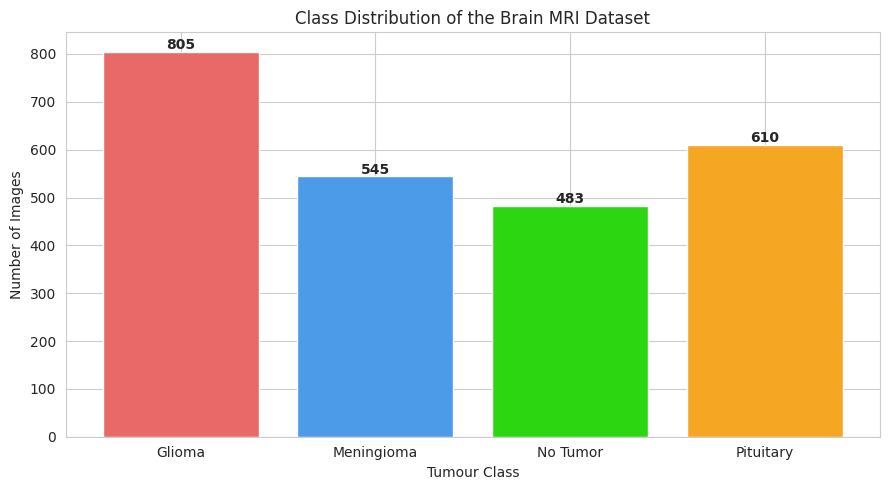

In [21]:
# Chart 1: number of images in each class
# count images per class and keep the alphabetical class order
counts = df["label"].value_counts().reindex(class_names)

plt.figure(figsize=(9, 5))

# draw one bar per class using the fixed class colours
bars = plt.bar(
    [PRETTY_NAMES[c] for c in counts.index],
    counts.values,
    color=[CLASS_COLORS[c] for c in counts.index],
)

# write the count above each bar
for bar, value in zip(bars, counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 5,
        str(value),
        ha="center",
        fontweight="bold",
    )

plt.xlabel("Tumour Class")

plt.ylabel("Number of Images")

plt.title("Class Distribution of the Brain MRI Dataset")

plt.tight_layout()

plt.savefig("images/chart1_class_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

##### **Key Insights**

- **Glioma is the most common class (805 images, 33.0%)**, followed by pituitary (610, 25.0%), meningioma (545, 22.3%) and no tumour (483, 19.8%).

- No class is extremely rare, so the problem is only mildly imbalanced. Plain accuracy would still hide weaker performance on the smaller classes, which is why **macro precision, recall and F1-score** are reported together with accuracy.

##### **Chart - 2 : Train / Validation / Test Split Sizes**

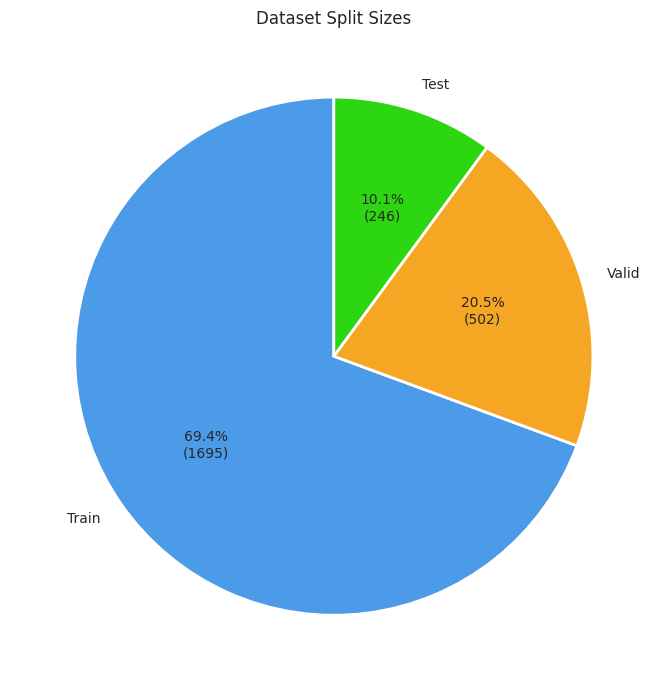

In [22]:
# Chart 2: share of images in each split
# count images per split in the logical order train -> valid -> test
split_counts = df["split"].value_counts().reindex(SPLITS)

plt.figure(figsize=(7, 7))

# pie chart with percentage labels
plt.pie(
    split_counts.values,
    labels=[s.capitalize() for s in split_counts.index],
    autopct=lambda p: f"{p:.1f}%\n({int(round(p * len(df) / 100))})",
    colors=["#4C9BE8", "#F5A623", "#2CD712"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)

plt.title("Dataset Split Sizes")

plt.tight_layout()

plt.savefig("images/chart2_split_sizes.png", dpi=300, bbox_inches="tight")

plt.show()

##### **Key Insights**

- The split is roughly **69% training, 21% validation and 10% test**.

- The test set is small (**246 images**), so each wrong prediction changes the test accuracy by about 0.4 percentage points. Small differences between models should therefore not be over-interpreted.

##### **Chart - 3 : Image File Size Distribution**

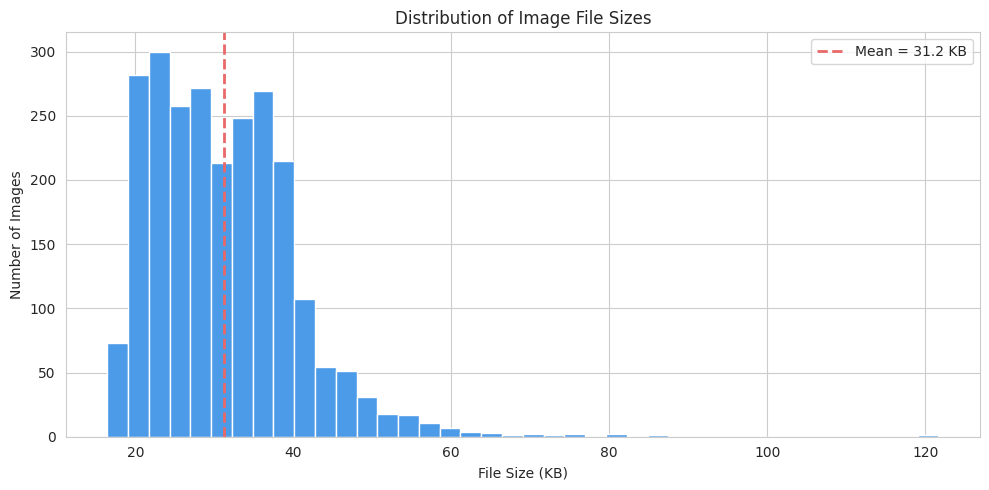

In [23]:
# Chart 3: histogram of file sizes in kilobytes
plt.figure(figsize=(10, 5))

# histogram of file sizes with 40 bins
plt.hist(df["file_size_kb"], bins=40, color="#4C9BE8", edgecolor="white")

# vertical line at the average file size
plt.axvline(
    df["file_size_kb"].mean(),
    color="#E96868",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {df['file_size_kb'].mean():.1f} KB",
)

plt.xlabel("File Size (KB)")

plt.ylabel("Number of Images")

plt.title("Distribution of Image File Sizes")

plt.legend()

plt.tight_layout()

plt.savefig("images/chart3_file_size_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

##### **Key Insights**

- File sizes are concentrated between roughly **24 KB and 37 KB** (average about **31 KB**), with a long tail of a few much larger files (up to about 122 KB).

- Because all images have the same pixel dimensions, file size reflects how much detail and brightness an image contains. This is explored further in Chart 6 and Chart 9.

#### **Bivariate Analysis**

##### **Chart - 4 : Class Distribution within Each Split**

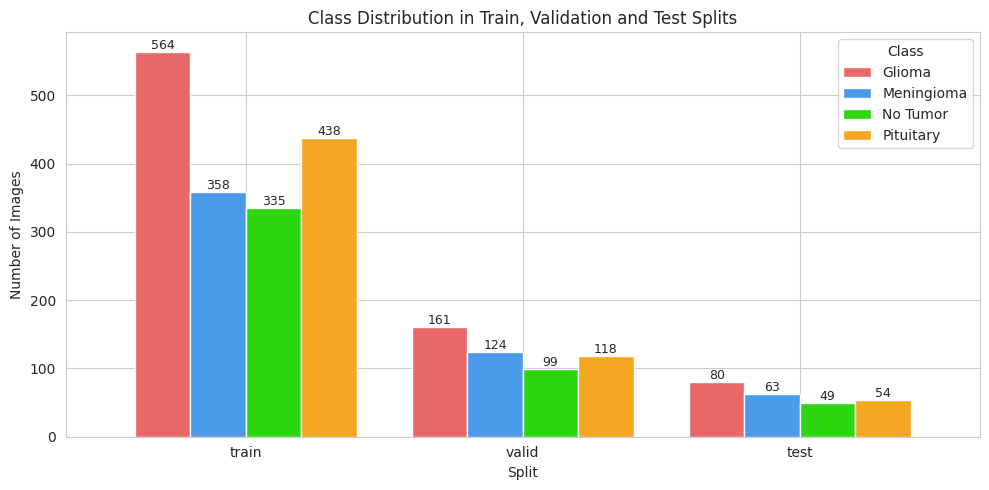

In [24]:
# Chart 4: grouped bar chart of class counts inside each split
# cross-tabulate: rows = split, columns = class
split_class = pd.crosstab(df["split"], df["label"]).reindex(SPLITS)

# draw the grouped bars
ax = split_class.plot(
    kind="bar",
    figsize=(10, 5),
    color=[CLASS_COLORS[c] for c in split_class.columns],
    edgecolor="white",
    width=0.8,
)

# write the counts above the bars
for container in ax.containers:
    ax.bar_label(container, fontsize=9)

plt.xlabel("Split")

plt.ylabel("Number of Images")

plt.title("Class Distribution in Train, Validation and Test Splits")

# readable legend and x labels
plt.xticks(rotation=0)
plt.legend([PRETTY_NAMES[c] for c in split_class.columns], title="Class")

plt.tight_layout()

plt.savefig("images/chart4_class_by_split.png", dpi=300, bbox_inches="tight")

plt.show()

##### **Key Insights**

- The **class proportions are similar in the three splits** (for example glioma is about 32-33% in every split and no tumour is about 20% in every split), so the validation and test sets represent the training distribution well.

- Two classes shift a little between splits: meningioma is about **21% of the training set** but about **25% of the validation set** and **26% of the test set**, while pituitary goes the other way (about **26%** in training, **24%** in validation and **22%** in test). These shifts are small but one more reason to look at per-class metrics.

##### **Chart - 5 : Sample MRI Images from Every Class**

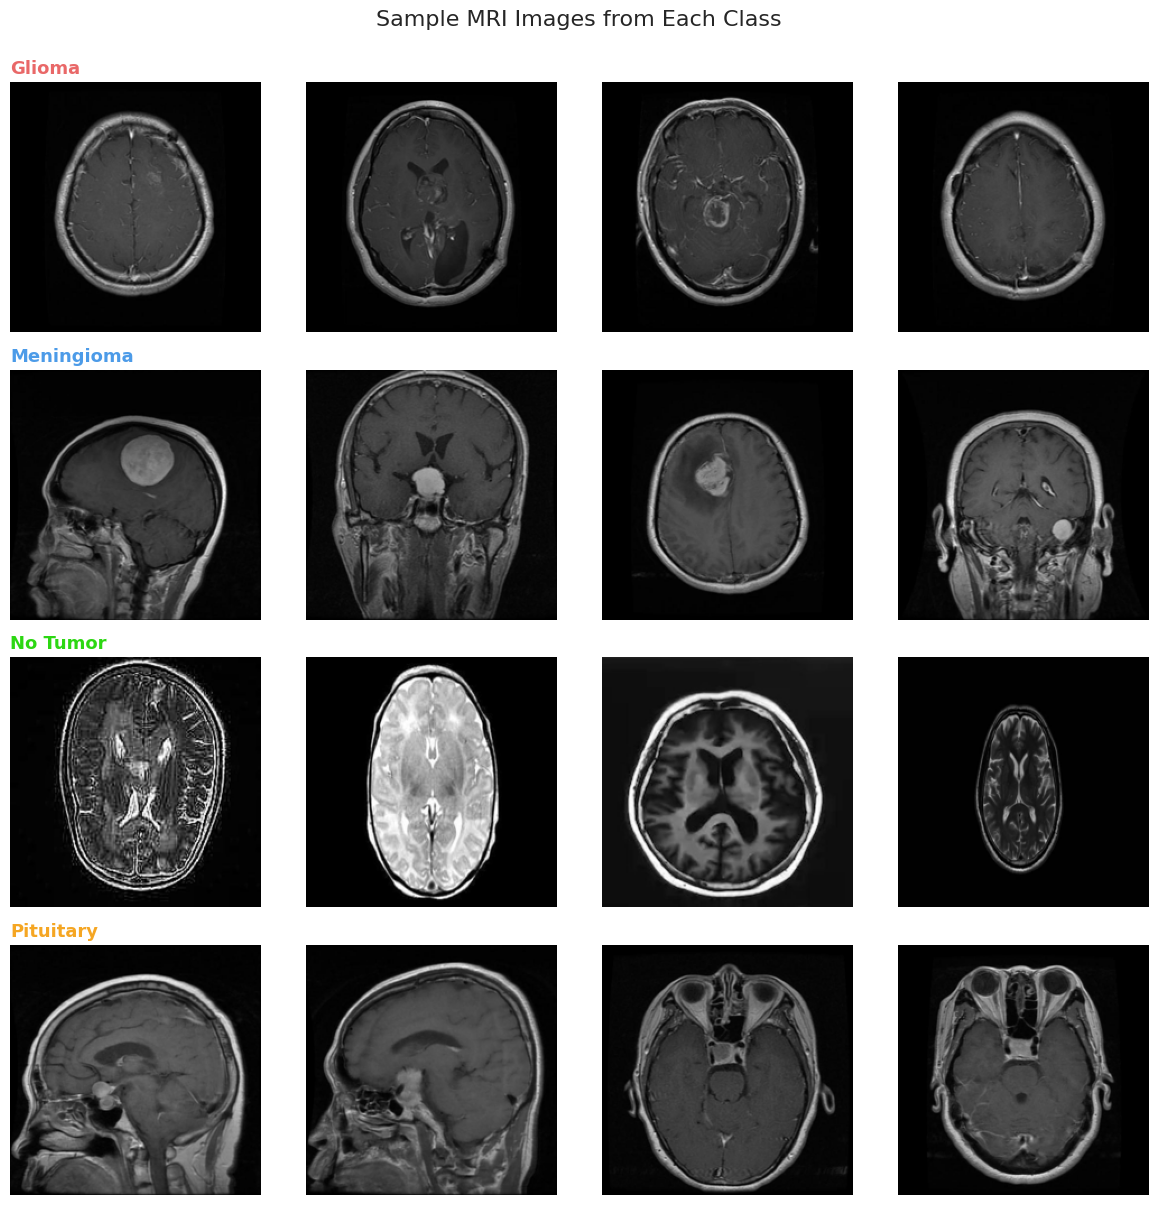

In [25]:
# Chart 5: 4 random example images for each tumour class
# number of example images per class
n_examples = 4

# create a grid: one row per class, one column per example
fig, axes = plt.subplots(
    NUM_CLASSES, n_examples, figsize=(3 * n_examples, 3 * NUM_CLASSES)
)

# go through each class (row)
for row_index, name in enumerate(class_names):
    # choose random images of this class
    chosen = df[df["label"] == name].sample(
        n=min(n_examples, (df["label"] == name).sum()), random_state=SEED
    )
    # draw each chosen image in its own cell
    for col_index in range(n_examples):
        # select the cell
        ax = axes[row_index, col_index]
        # if we have an image for this cell, show it
        if col_index < len(chosen):
            # protect against unreadable files
            try:
                # open and resize the image for display
                with Image.open(chosen.iloc[col_index]["filepath"]) as img:
                    ax.imshow(img.convert("RGB").resize(IMG_SIZE))
            except Exception:
                ax.text(0.5, 0.5, "unreadable", ha="center")
        # hide the axis ticks
        ax.axis("off")
        # write the class name above the first image of each row
        if col_index == 0:
            ax.set_title(
                PRETTY_NAMES[name],
                fontsize=13,
                fontweight="bold",
                loc="left",
                color=CLASS_COLORS[name],
            )

plt.suptitle("Sample MRI Images from Each Class", fontsize=16, y=1.0)

plt.tight_layout()

plt.savefig("images/chart5_sample_images.png", dpi=300, bbox_inches="tight")

plt.show()

##### **Key Insights**

- The images come from **different viewing planes** (axial, sagittal and coronal) and different scan settings, so the model has to cope with a lot of visual variety.

- **Glioma** samples mostly show axial slices with a darker, uneven mass inside the brain. **Meningioma** samples show a bright, round mass close to the skull or the base of the brain. **Pituitary** samples are mainly sagittal and axial views near the centre of the skull, around the sella region.

- The **no-tumour** samples visibly look different in contrast and style from the tumour classes (some are much brighter or have a different scan appearance). This is a warning sign: a model could learn the *scan style* instead of the *tumour itself*. This is one more reason to look at confusion matrices and misclassified examples, not only at accuracy.

##### **Chart - 6 : Mean Image Brightness by Class**

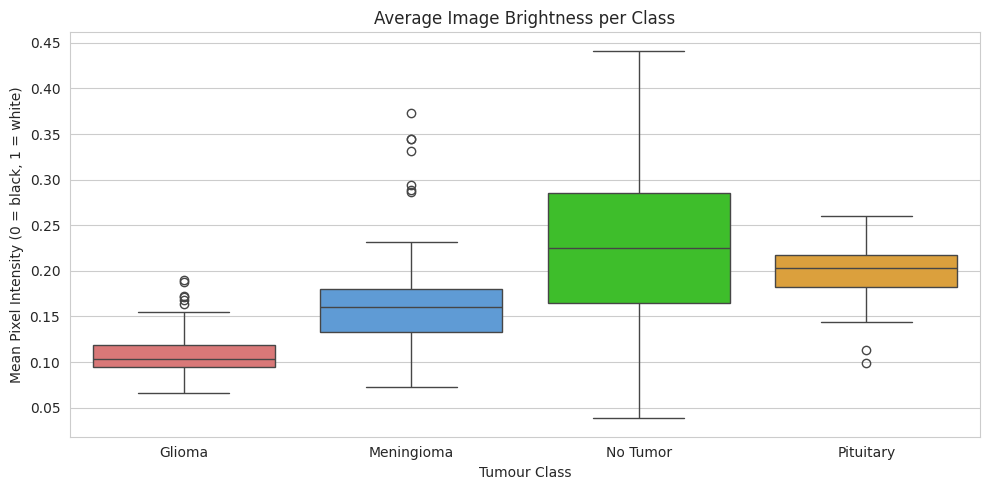

In [26]:
# Chart 6: boxplot of average brightness of images in each class
plt.figure(figsize=(10, 5))

# one box per class; order follows the class_names list
sns.boxplot(
    data=sample_df,
    x="label",
    y="mean_intensity",
    order=class_names,
    palette=CLASS_COLORS,
    hue="label",
    legend=False,
)

plt.xlabel("Tumour Class")

plt.ylabel("Mean Pixel Intensity (0 = black, 1 = white)")

plt.title("Average Image Brightness per Class")

# use pretty class names on the x axis
plt.xticks(range(NUM_CLASSES), [PRETTY_NAMES[c] for c in class_names])

plt.tight_layout()

plt.savefig("images/chart6_brightness_by_class.png", dpi=300, bbox_inches="tight")

plt.show()

##### **Key Insights**

- In the sampled images, the classes clearly differ in average brightness: **glioma is the darkest** (mean about 0.11), then **meningioma** (about 0.17), **pituitary** (about 0.20) and **no tumour is the brightest** (about 0.24).

- No-tumour images also have the widest spread, which matches the very different scan styles seen in Chart 5.

- Brightness alone separates the classes only partly (the boxes overlap), but this shows that simple intensity statistics already carry class information. A deep model may partly use this, so the **brightness augmentation** used later also helps the model not to depend only on brightness.

#### **Multivariate Analysis**

##### **Chart - 7 : Average MRI Image of Each Class**

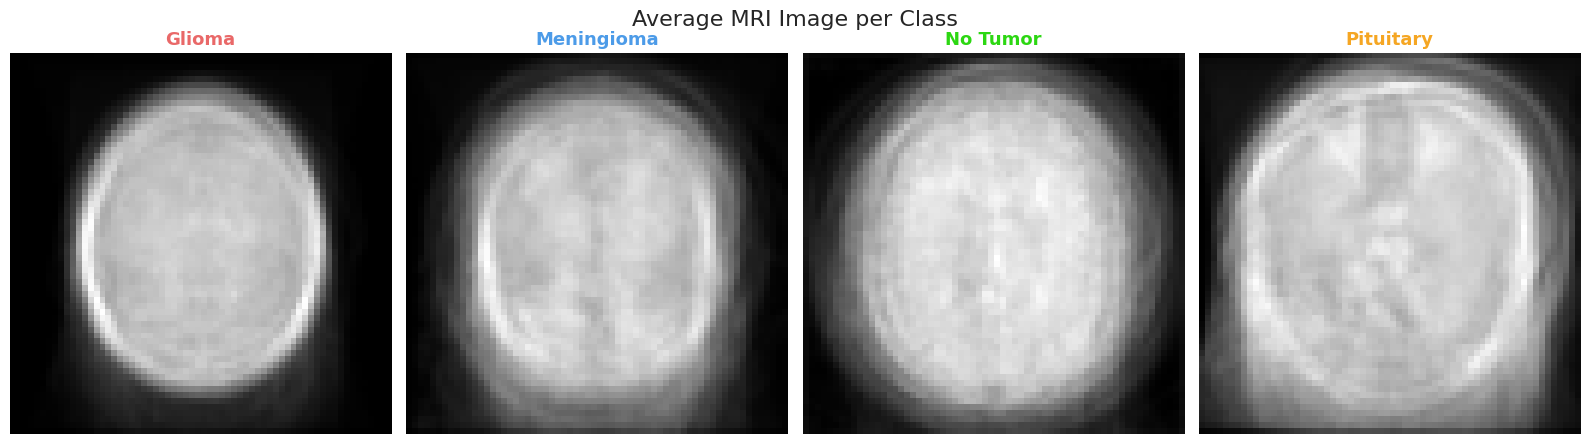

In [27]:
# Chart 7: pixel-wise average of all sampled images of each class
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(4 * NUM_CLASSES, 4.5))

# draw the mean image of each class
for ax, name in zip(axes, class_names):
    # stack the small images into one array and average across all images
    mean_image = np.mean(np.stack(sample_images[name]), axis=0)
    # show the average image in grayscale
    ax.imshow(mean_image, cmap="gray")
    # title with the class name
    ax.set_title(
        PRETTY_NAMES[name], fontsize=13, fontweight="bold", color=CLASS_COLORS[name]
    )
    # hide the axis
    ax.axis("off")

plt.suptitle("Average MRI Image per Class", fontsize=16)

plt.tight_layout()

plt.savefig("images/chart7_average_image_per_class.png", dpi=300, bbox_inches="tight")

plt.show()

##### **Key Insights**

- The **average image of every class looks like a blurred brain**, because the scans are taken from different planes and positions. Class differences are therefore not visible in a simple average, which shows the task needs a model that learns local patterns and not just global shape.

- The glioma average is the darkest and forms a clean, compact axial oval, which shows that most glioma scans share the same viewing plane. The no-tumour average is the brightest, matching Chart 6, and the pituitary average keeps some sagittal-style structure in the centre.

##### **Chart - 8 : Pixel Intensity Distribution by Class**

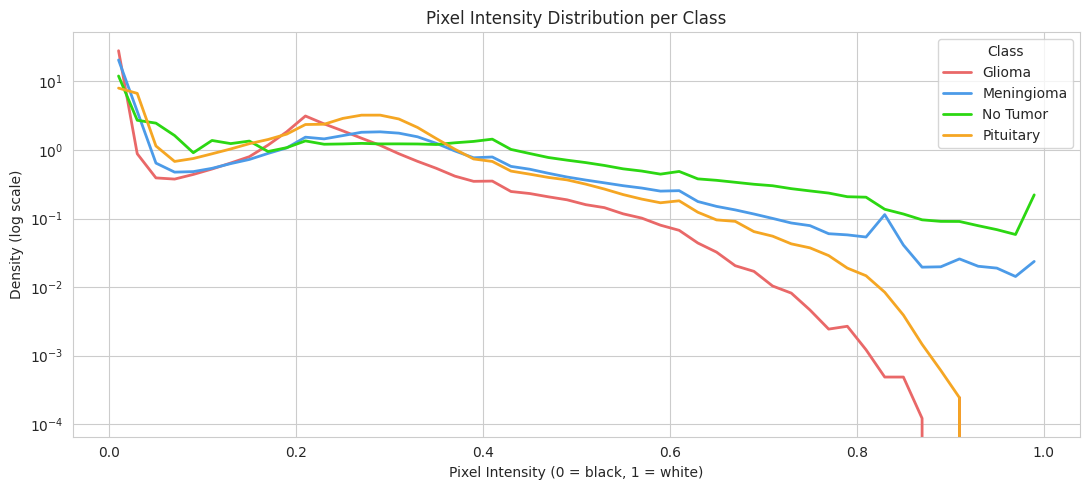

In [28]:
# Chart 8: histogram of all pixel values for every class (overlaid)
plt.figure(figsize=(11, 5))

# draw one line per class
for name in class_names:
    # flatten all sampled images of this class into one long list of pixel values
    pixels = np.concatenate([img.ravel() for img in sample_images[name]])
    # compute a histogram (density = area under the curve is 1) with 50 bins
    hist, edges = np.histogram(pixels, bins=50, range=(0, 1), density=True)
    # use the middle of each bin as the x position
    centers = (edges[:-1] + edges[1:]) / 2
    # draw the curve
    plt.plot(
        centers, hist, label=PRETTY_NAMES[name], color=CLASS_COLORS[name], linewidth=2
    )

# the background of MRI scans is black, so the first bin is huge; a log scale keeps other details visible
plt.yscale("log")

plt.xlabel("Pixel Intensity (0 = black, 1 = white)")

plt.ylabel("Density (log scale)")

plt.title("Pixel Intensity Distribution per Class")

plt.legend(title="Class")

plt.tight_layout()

plt.savefig(
    "images/chart8_pixel_intensity_distribution.png", dpi=300, bbox_inches="tight"
)

plt.show()

##### **Key Insights**

- Every class has a **very large peak at dark pixel values**, because MRI scans have a black background. The log scale is used so that the rest of the distribution stays visible.

- Roughly **58% of glioma pixels and 49% of meningioma pixels are almost black**, compared with about **31% for no tumour and pituitary** (in the sampled images). The no-tumour class also has the largest share of very bright pixels.

- These differences confirm that the classes are not identical in their intensity profile, which supports using normalisation and brightness / contrast augmentation.

##### **Chart - 9 : File Size vs Mean Brightness (Coloured by Class)**

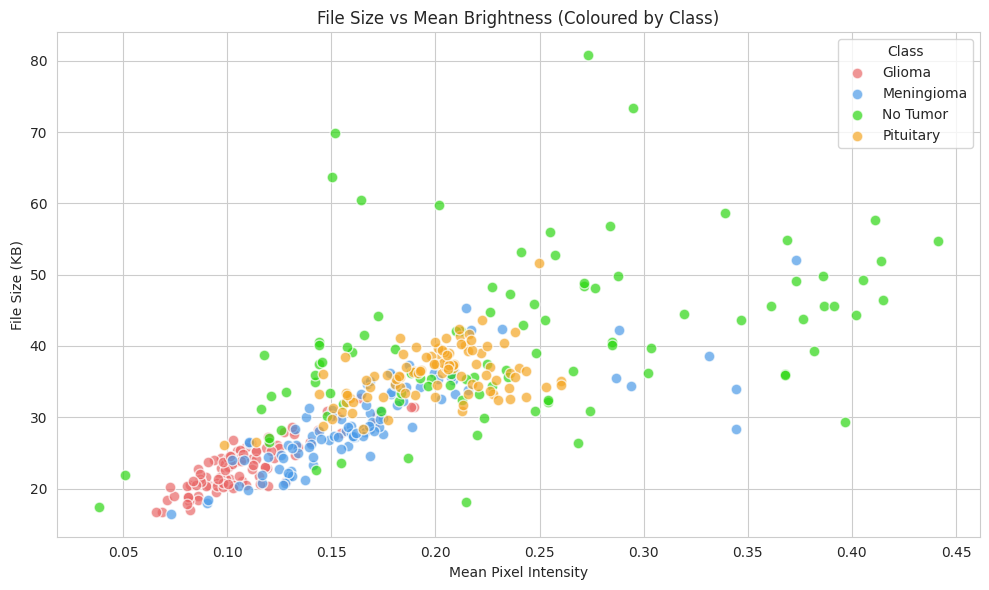

In [29]:
# Chart 9: scatter plot of file size against mean brightness for the sampled images
plt.figure(figsize=(10, 6))

# draw one cloud of points per class
for name in class_names:
    # rows of this class
    subset = sample_df[sample_df["label"] == name]
    # scatter plot of the two variables
    plt.scatter(
        subset["mean_intensity"],
        subset["file_size_kb"],
        label=PRETTY_NAMES[name],
        color=CLASS_COLORS[name],
        alpha=0.7,
        edgecolor="white",
        s=60,
    )

plt.xlabel("Mean Pixel Intensity")

plt.ylabel("File Size (KB)")

plt.title("File Size vs Mean Brightness (Coloured by Class)")

plt.legend(title="Class")

plt.tight_layout()

plt.savefig("images/chart9_filesize_vs_brightness.png", dpi=300, bbox_inches="tight")

plt.show()

##### **Key Insights**

- File size and mean brightness have a **strong positive relationship** (correlation about **0.73** in the sample): brighter images contain more information and compress to larger files.

- The classes form partly separate clouds: glioma points sit at the low-brightness and small-file corner, while no-tumour points reach the highest brightness and file sizes.

- This is another hint that acquisition style differs between classes, and a reminder that a high test accuracy should be checked with misclassified examples and confusion matrices.

#### **5. Data Preprocessing and Augmentation**

##### **1. Train / Validation / Test Tables and Numeric Labels**

In [30]:
# neural networks need numbers, so every class name gets an index: glioma = 0, meningioma = 1, ...
class_to_index = {name: index for index, name in enumerate(class_names)}
# reverse dictionary: index -> class name (used when we read model predictions)
index_to_class = {index: name for name, index in class_to_index.items()}
# add the numeric label as a new column
df["label_id"] = df["label"].map(class_to_index)

# split the big table into three smaller tables using the folders that came with the dataset
train_df = df[df["split"] == "train"].reset_index(drop=True)
valid_df = df[df["split"] == "valid"].reset_index(drop=True)
test_df = df[df["split"] == "test"].reset_index(drop=True)

print("Class -> index mapping :", class_to_index)
print(f"Train : {len(train_df)} | Validation : {len(valid_df)} | Test : {len(test_df)}")

Class -> index mapping : {'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}
Train : 1695 | Validation : 502 | Test : 246


##### **2. Resizing and Normalisation Pipeline (tf.data)**

In [31]:
# AUTOTUNE lets TensorFlow choose the best number of parallel workers automatically
AUTOTUNE = tf.data.AUTOTUNE


# function 1: read one image file from disk and resize it to 224 x 224
def load_and_resize(file_path, label):
    # read the raw bytes of the file
    image_bytes = tf.io.read_file(file_path)
    # decode the bytes into an image with exactly 3 colour channels (RGB)
    image = tf.io.decode_image(
        image_bytes, channels=IMG_CHANNELS, expand_animations=False
    )
    # tell TensorFlow that the image has 3 channels (needed because decode_image returns an unknown shape)
    image.set_shape([None, None, IMG_CHANNELS])
    # resize every image to the same size (224 x 224)
    image = tf.image.resize(image, IMG_SIZE)
    # round and store as small integers (uint8) so the in-memory cache uses 4x less RAM
    image = tf.cast(tf.clip_by_value(tf.round(image), 0, 255), tf.uint8)
    # return the image and its label
    return image, label


# function 2: normalize pixel values from the range 0-255 to the range 0-1
def normalize(image, label):
    # convert integers to decimals and divide by 255
    image = tf.cast(image, tf.float32) / 255.0
    # return the normalised image and its label
    return image, label

##### **3. Data Augmentation Layers**

In [32]:
# These layers create slightly changed copies of the training images on the fly.
# This shows the model more variety and helps it generalize instead of memorizing.
data_augmentation = keras.Sequential(
    [
        # randomly flip images left-right and up-down
        layers.RandomFlip("horizontal_and_vertical"),
        # randomly rotate by up to +/- 5 % of a full turn (about 18 degrees); empty corners are filled with black
        layers.RandomRotation(0.05, fill_mode="constant", fill_value=0.0),
        # randomly zoom in or out by up to 15 %
        layers.RandomZoom(0.15, fill_mode="constant", fill_value=0.0),
        # randomly shift the image up/down/left/right by up to 10 %
        layers.RandomTranslation(0.1, 0.1, fill_mode="constant", fill_value=0.0),
        # randomly make the image brighter or darker (value_range tells Keras our pixels are in 0-1)
        layers.RandomBrightness(0.2, value_range=(0.0, 1.0)),
        # randomly change the contrast
        layers.RandomContrast(0.2),
    ],
    name="data_augmentation",
)


# function that applies the augmentation to a batch and keeps pixel values inside 0-1
def augment(images, labels):
    # training = True switches the random layers on
    images = data_augmentation(images, training=True)
    # make sure no pixel went outside the 0-1 range
    images = tf.clip_by_value(images, 0.0, 1.0)
    # return the augmented images with their labels
    return images, labels

##### **4. Build the Final Datasets**

In [33]:
# function that turns a table of image paths + labels into a ready-to-train tf.data pipeline
def make_dataset(frame, training=False):
    # list of file paths
    paths = frame["filepath"].values
    # one-hot labels, for example class 2 of 4 becomes [0, 0, 1, 0]
    labels = keras.utils.to_categorical(frame["label_id"].values, NUM_CLASSES)
    # create a dataset from the two lists
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    # load and resize every image in parallel
    dataset = dataset.map(load_and_resize, num_parallel_calls=AUTOTUNE)
    # keep the resized images in memory so they are not re-read from disk every epoch
    dataset = dataset.cache()
    # only the training data is shuffled; validation and test keep their order so metrics line up with labels
    if training:
        dataset = dataset.shuffle(len(frame), seed=SEED, reshuffle_each_iteration=True)
    # normalize pixel values to 0-1
    dataset = dataset.map(normalize, num_parallel_calls=AUTOTUNE)
    # group images into batches
    dataset = dataset.batch(BATCH_SIZE)
    # augment only the training batches
    if training:
        dataset = dataset.map(augment, num_parallel_calls=AUTOTUNE)
    # prepare the next batch while the current one is being used by the model
    return dataset.prefetch(AUTOTUNE)


# build the three datasets inside try/except so a broken file gives a clear error
try:
    train_ds = make_dataset(train_df, training=True)
    val_ds = make_dataset(valid_df, training=False)
    test_ds = make_dataset(test_df, training=False)
    print("tf.data pipelines created successfully.")
except Exception as error:
    print("Could not build the datasets:", error)
    raise

tf.data pipelines created successfully.


##### **5. Verify the Preprocessing**

In [34]:
# take one batch from the validation dataset to check shapes and value ranges
sample_batch_images, sample_batch_labels = next(iter(val_ds))

print("Image batch shape :", sample_batch_images.shape)
print("Label batch shape :", sample_batch_labels.shape)
print(
    "Pixel min / max   :",
    float(tf.reduce_min(sample_batch_images)),
    "/",
    float(tf.reduce_max(sample_batch_images)),
)

# assert = stop immediately with a message if the condition is False
assert (
    sample_batch_images.shape[1:] == INPUT_SHAPE
), "Images do not have the expected shape."
assert (
    0.0 <= float(tf.reduce_min(sample_batch_images))
    and float(tf.reduce_max(sample_batch_images)) <= 1.0
), "Pixels are not in 0-1."
print("Preprocessing check passed : shape is correct and pixels are normalised to 0-1.")

Image batch shape : (32, 224, 224, 3)
Label batch shape : (32, 4)
Pixel min / max   : 0.0 / 0.9921568632125854
Preprocessing check passed : shape is correct and pixels are normalised to 0-1.


##### **6. Visualising Data Augmentation**

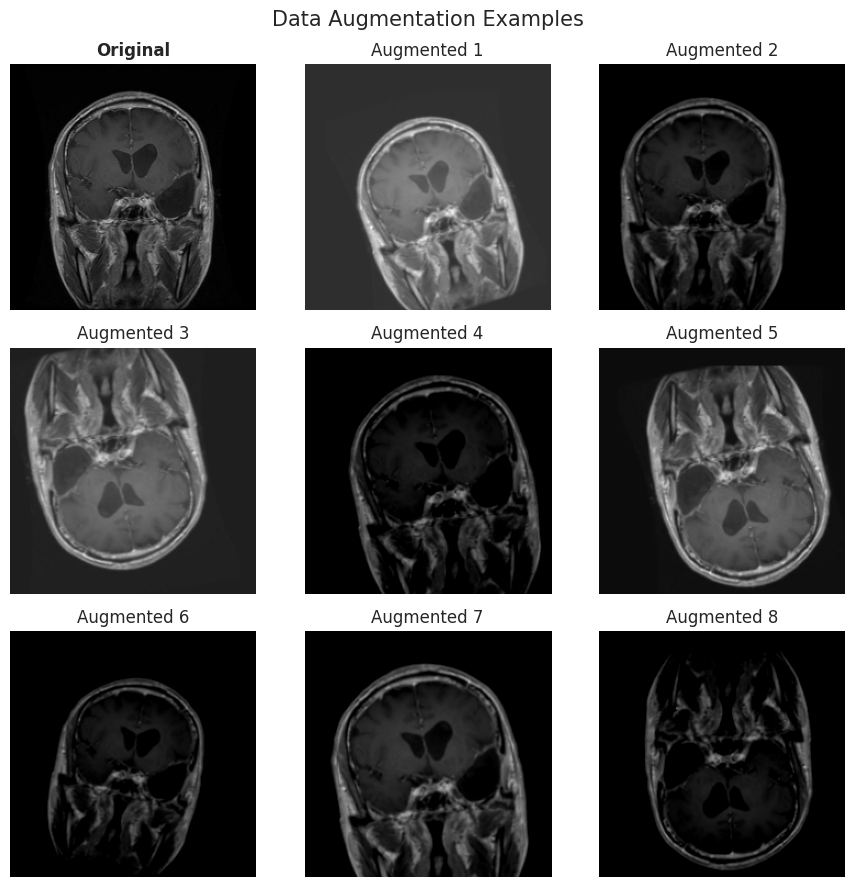

In [35]:
# take the first validation image and repeat it 8 times, then augment each copy differently
original = sample_batch_images[0:1]
# repeat the same image 8 times
repeated = tf.repeat(original, repeats=8, axis=0)
# apply random augmentation to each copy
augmented, _ = augment(repeated, None)

# draw the original and 8 augmented versions
fig, axes = plt.subplots(3, 3, figsize=(9, 9))

# the first cell shows the original
axes[0, 0].imshow(original[0].numpy())
axes[0, 0].set_title("Original", fontweight="bold")
axes[0, 0].axis("off")

# the other 8 cells show augmented copies
for i in range(8):
    # compute the row and column of the cell
    ax = axes[(i + 1) // 3, (i + 1) % 3]
    ax.imshow(augmented[i].numpy())
    ax.set_title(f"Augmented {i + 1}")
    ax.axis("off")

plt.suptitle("Data Augmentation Examples", fontsize=15)

plt.tight_layout()

plt.savefig("images/chart10_augmentation_examples.png", dpi=300, bbox_inches="tight")

plt.show()

##### **7. Class Weights (Handling Class Imbalance)**

In [36]:
# 'balanced' gives smaller classes a bigger weight so the model pays equal attention to every class
weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_df["label_id"].values,
)
# keras expects a dictionary {class index: weight}
class_weights = {index: float(weight) for index, weight in enumerate(weights_array)}

# print the weights with the class names to make them easy to read
for index, weight in class_weights.items():
    print(f"{index_to_class[index]:<12} -> weight {weight:.3f}")

glioma       -> weight 0.751
meningioma   -> weight 1.184
no_tumor     -> weight 1.265
pituitary    -> weight 0.967


##### **Key Insights**

- Every image is **resized to 224 x 224** and its pixel values are **normalised to the 0-1 range**. The verification cell confirms the batch shape `(batch, 224, 224, 3)` and that all pixel values are between 0 and 1.

- The `tf.data` pipeline **caches the resized images as small integers**, so images are read from disk only once, which makes every later epoch much faster and uses far less memory.

- **Augmentation is applied only to the training data**: rotation, horizontal and vertical flips, zoom, shifts, brightness and contrast changes. Validation and test images are never augmented, so evaluation stays fair. Note that brightness changes also lift the black background slightly, which is visible in some augmented examples; this is harmless but explains the grey background in a few of them.

- **Class weights** give the smaller classes (no tumour: about 1.27, meningioma: about 1.18) a larger influence and the largest class (glioma: about 0.75) a smaller one, which counters the imbalance found in Section 3.

#### **6. Model Building, Training and Evaluation**

##### **Reusable Helper Functions**

In [37]:
# dictionary that will store everything we learn about each model (history, metrics, size, time ...)
results = {}

# where each trained model is saved (.h5 files, as required by the project)
MODEL_PATHS = {
    "Custom CNN": os.path.join(MODELS_DIR, "custom_cnn.h5"),
    "MobileNetV2": os.path.join(MODELS_DIR, "mobilenetv2.h5"),
    "ResNet50V2": os.path.join(MODELS_DIR, "resnet50v2.h5"),
    "InceptionV3": os.path.join(MODELS_DIR, "inceptionv3.h5"),
    "EfficientNetB0": os.path.join(MODELS_DIR, "efficientnetb0.h5"),
}


# function: creates the three callbacks that control training
def get_callbacks(checkpoint_path, patience, initial_threshold=None):
    # list of callbacks returned to model.fit
    return [
        # stop training when validation loss has not improved for `patience` epochs and go back to the best weights
        EarlyStopping(
            monitor="val_loss", patience=patience, restore_best_weights=True, verbose=1
        ),
        # save the model to disk every time validation loss improves (so only the best model is kept)
        ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_loss",
            save_best_only=True,
            initial_value_threshold=initial_threshold,
            verbose=0,
        ),
        # reduce the learning rate when validation loss stops improving (smaller steps = finer learning)
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=max(1, patience // 2),
            min_lr=1e-7,
            verbose=1,
        ),
    ]


# function: joins the history of two training phases into one history
def merge_histories(first, second):
    # keep only keys that exist in both histories and join the two lists
    return {key: list(first[key]) + list(second[key]) for key in first if key in second}


# function: draws accuracy and loss curves of one model
def plot_history(history, title, save_name, fine_tune_start=None):
    # epoch numbers start at 1
    epochs_range = range(1, len(history["loss"]) + 1)
    # two charts side by side: accuracy and loss
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    # ---- accuracy chart ----
    axes[0].plot(
        epochs_range,
        history["accuracy"],
        marker="o",
        label="Training Accuracy",
        color="#4C9BE8",
    )
    axes[0].plot(
        epochs_range,
        history["val_accuracy"],
        marker="o",
        label="Validation Accuracy",
        color="#E96868",
    )
    axes[0].set_title(f"{title} - Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    # ---- loss chart ----
    axes[1].plot(
        epochs_range,
        history["loss"],
        marker="o",
        label="Training Loss",
        color="#4C9BE8",
    )
    axes[1].plot(
        epochs_range,
        history["val_loss"],
        marker="o",
        label="Validation Loss",
        color="#E96868",
    )
    axes[1].set_title(f"{title} - Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    # for transfer learning, draw a dashed line where fine-tuning started
    if fine_tune_start is not None:
        for ax in axes:
            ax.axvline(
                fine_tune_start + 0.5,
                color="gray",
                linestyle="--",
                label="Fine-tuning starts",
            )
    # show the legends
    for ax in axes:
        ax.legend()
    plt.tight_layout()
    plt.savefig(f"images/{save_name}", dpi=300, bbox_inches="tight")
    plt.show()


# function: draws a confusion matrix as a heatmap
def plot_confusion_matrix(cm, title, save_name):
    # percentage version: each row is divided by its total, so we see the recall of every class
    cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100
    # labels that show both the count and the percentage in every cell
    annotations = np.array(
        [
            [f"{cm[i, j]}\n({cm_percent[i, j]:.1f}%)" for j in range(cm.shape[1])]
            for i in range(cm.shape[0])
        ]
    )
    plt.figure(figsize=(8, 6.5))
    # draw the heatmap
    sns.heatmap(
        cm_percent,
        annot=annotations,
        fmt="",
        cmap="Blues",
        cbar=True,
        xticklabels=[PRETTY_NAMES[c] for c in class_names],
        yticklabels=[PRETTY_NAMES[c] for c in class_names],
    )
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f"images/{save_name}", dpi=300, bbox_inches="tight")
    plt.show()


# function: computes all metrics of a model on one dataset
def evaluate_split(model, dataset, y_true):
    # predicted probability for every class, one row per image
    probabilities = model.predict(dataset, verbose=0)
    # the predicted class is the one with the highest probability
    y_pred = np.argmax(probabilities, axis=1)
    # index of the "no_tumor" class (used for the tumour sensitivity metric)
    no_tumor_index = class_to_index.get("no_tumor", None)
    # tumour sensitivity = of all images that really contain a tumour, how many were NOT called "no tumour"
    tumour_mask = (
        (y_true != no_tumor_index)
        if no_tumor_index is not None
        else np.ones_like(y_true, dtype=bool)
    )
    tumour_sensitivity = (
        float(np.mean(y_pred[tumour_mask] != no_tumor_index))
        if no_tumor_index is not None
        else np.nan
    )
    # collect all metrics in one dictionary (macro = average of the classes with equal importance)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "tumour_sensitivity": tumour_sensitivity,
        "per_class_f1": f1_score(
            y_true, y_pred, average=None, labels=np.arange(NUM_CLASSES), zero_division=0
        ),
        "per_class_recall": recall_score(
            y_true, y_pred, average=None, labels=np.arange(NUM_CLASSES), zero_division=0
        ),
        "y_pred": y_pred,
        "probabilities": probabilities,
    }


# function: full evaluation report of one trained model (validation + test metrics, report, plots)
def evaluate_and_report(model_name, fine_tune_start=None):
    # stop early with a message if this model was not trained successfully
    if model_name not in results or "history" not in results[model_name]:
        print(f"{model_name} was not trained, nothing to evaluate.")
        return
    # path of the best saved version of this model
    path = MODEL_PATHS[model_name]
    # load the best saved model (the one with the lowest validation loss); compile = False because we only need predictions
    try:
        model = keras.models.load_model(path, compile=False)
    # if loading fails we cannot evaluate, so report and stop
    except Exception as error:
        print(f"Could not load {path}: {error}")
        return
    # true labels in the same order as the (unshuffled) datasets
    y_val, y_test = valid_df["label_id"].values, test_df["label_id"].values
    # evaluate on the validation set (used later to choose the best model)
    val_metrics = evaluate_split(model, val_ds, y_val)
    # time one full pass over the test set to estimate the inference speed
    start = time.time()
    test_metrics = evaluate_split(model, test_ds, y_test)
    inference_ms = (time.time() - start) / len(y_test) * 1000
    # store the numbers for the comparison section
    results[model_name].update(
        {
            "val": val_metrics,
            "test": test_metrics,
            "inference_ms": inference_ms,
            "params": model.count_params(),
            "size_mb": os.path.getsize(path) / (1024 * 1024),
        }
    )
    # print the headline numbers
    print(
        f"{model_name} | Validation accuracy : {val_metrics['accuracy']:.4f} | Test accuracy : {test_metrics['accuracy']:.4f}"
    )
    print(
        f"{model_name} | Test Precision (macro) : {test_metrics['precision_macro']:.4f} | Recall (macro) : {test_metrics['recall_macro']:.4f} | F1 (macro) : {test_metrics['f1_macro']:.4f}"
    )
    # detailed per-class report
    print("\nClassification Report (Test Set)")
    print(
        classification_report(
            y_test,
            test_metrics["y_pred"],
            target_names=[PRETTY_NAMES[c] for c in class_names],
            zero_division=0,
        )
    )
    # confusion matrix heatmap
    cm = confusion_matrix(y_test, test_metrics["y_pred"], labels=np.arange(NUM_CLASSES))
    results[model_name]["confusion_matrix"] = cm
    safe_name = model_name.lower().replace(" ", "_")
    plot_confusion_matrix(
        cm,
        f"{model_name} - Confusion Matrix (Test Set)",
        f"confusion_matrix_{safe_name}.png",
    )
    # training curves
    plot_history(
        results[model_name]["history"],
        model_name,
        f"training_history_{safe_name}.png",
        fine_tune_start,
    )


print("Helper functions are ready.")

Helper functions are ready.


#### **ML Model - 1 : Custom CNN (Built from Scratch)**

##### **Step 1 : Architecture**

The custom CNN stacks **4 convolutional blocks** (32, 64, 128 and 256 filters). Every convolution is followed by **Batch Normalization** (stabilises and speeds up learning) and a **ReLU** activation. Each block ends with **Max Pooling** (shrinks the image) and **Dropout** (randomly switches off neurons to reduce overfitting). **Global Average Pooling** then turns the feature maps into a compact vector, which goes through one **Dense** layer with Dropout, and finally a **Softmax** layer that outputs one probability per tumour class.

In [38]:
# function that builds the custom CNN from scratch
def build_custom_cnn(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    # Sequential = layers are stacked one after another
    model = keras.Sequential(name="custom_cnn")
    # the input layer defines the shape of one image
    model.add(layers.Input(shape=input_shape))
    # each tuple is (number of filters, number of convolutions in the block)
    for filters, n_convs in [(32, 1), (64, 2), (128, 2), (256, 2)]:
        # repeat the convolution as many times as needed in this block
        for _ in range(n_convs):
            # convolution layer looks for patterns (edges, textures, shapes)
            model.add(layers.Conv2D(filters, (3, 3), padding="same", use_bias=False))
            # batch normalization keeps values stable during training
            model.add(layers.BatchNormalization())
            # ReLU keeps positive values and sets negative values to 0
            model.add(layers.Activation("relu"))
        # max pooling halves the width and height of the feature maps
        model.add(layers.MaxPooling2D((2, 2)))
        # dropout randomly switches off 25 % of the neurons while training
        model.add(layers.Dropout(0.25))
    # average every feature map into a single number
    model.add(layers.GlobalAveragePooling2D())
    # fully connected layer that combines the learned features
    model.add(layers.Dense(256, activation="relu"))
    # stronger dropout before the output layer
    model.add(layers.Dropout(0.5))
    # output layer: one probability per class (they add up to 1)
    model.add(layers.Dense(num_classes, activation="softmax"))
    # return the finished model
    return model


# create the model and show its summary
custom_cnn = build_custom_cnn()
custom_cnn.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,232,612 (4.70 MB)

 Trainable params: 1,230,756 (4.69 MB)

 Non-trainable params: 1,856 (7.25 KB)

##### **Step 2 : Compile and Train**

In [39]:
# compile = choose optimizer, loss and metric
custom_cnn.compile(
    # Adam is a popular optimizer that adapts the learning rate automatically
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    # categorical crossentropy is the standard loss for multi-class problems with one-hot labels
    loss="categorical_crossentropy",
    # track accuracy during training
    metrics=["accuracy"],
)

# remember the time before training starts
start_time = time.time()

# train inside try/except so that errors (for example out of memory) show a helpful message
try:
    history_cnn = custom_cnn.fit(
        train_ds,
        validation_data=val_ds,
        epochs=CUSTOM_CNN_EPOCHS,
        callbacks=get_callbacks(MODEL_PATHS["Custom CNN"], EARLY_STOP_PATIENCE),
        class_weight=class_weights,
        verbose=FIT_VERBOSE,
    )
    # store the training history and training time
    results["Custom CNN"] = {
        "history": history_cnn.history,
        "train_time_min": (time.time() - start_time) / 60,
        "weights": "random (trained from scratch)",
    }
    print(
        f"\nTraining finished in {results['Custom CNN']['train_time_min']:.1f} minutes. Best model saved to {MODEL_PATHS['Custom CNN']}"
    )
# an out-of-memory error usually means the batch size is too large
except tf.errors.ResourceExhaustedError:
    print("Out of memory. Reduce BATCH_SIZE in the configuration cell and run again.")
# any other error is printed so we can understand what happened
except Exception as error:
    print("Training failed:", error)

Epoch 1/30


53/53 - 73s - 1s/step - accuracy: 0.5192 - loss: 1.2092 - val_accuracy: 0.3207 - val_loss: 4.9090 - learning_rate: 0.0010
Epoch 2/30


53/53 - 44s - 828ms/step - accuracy: 0.5917 - loss: 1.0133 - val_accuracy: 0.3207 - val_loss: 4.6350 - learning_rate: 0.0010
Epoch 3/30


53/53 - 23s - 435ms/step - accuracy: 0.6000 - loss: 1.0214 - val_accuracy: 0.3207 - val_loss: 3.5902 - learning_rate: 0.0010
Epoch 4/30
53/53 - 41s - 770ms/step - accuracy: 0.6236 - loss: 0.9358 - val_accuracy: 0.3207 - val_loss: 5.0224 - learning_rate: 0.0010
Epoch 5/30


53/53 - 30s - 561ms/step - accuracy: 0.6088 - loss: 0.9642 - val_accuracy: 0.3327 - val_loss: 2.4747 - learning_rate: 0.0010
Epoch 6/30
53/53 - 21s - 405ms/step - accuracy: 0.6496 - loss: 0.8864 - val_accuracy: 0.3207 - val_loss: 4.6613 - learning_rate: 0.0010
Epoch 7/30


...

53/53 - 21s - 403ms/step - accuracy: 0.7835 - loss: 0.5772 - val_accuracy: 0.6952 - val_loss: 0.7259 - learning_rate: 3.0000e-04
Epoch 13/30


53/53 - 23s - 441ms/step - accuracy: 0.7847 - loss: 0.5879 - val_accuracy: 0.7610 - val_loss: 0.5859 - learning_rate: 3.0000e-04
Epoch 14/30


53/53 - 22s - 412ms/step - accuracy: 0.7858 - loss: 0.5604 - val_accuracy: 0.8127 - val_loss: 0.5151 - learning_rate: 3.0000e-04
Epoch 15/30
53/53 - 41s - 765ms/step - accuracy: 0.7817 - loss: 0.5573 - val_accuracy: 0.7052 - val_loss: 0.8117 - learning_rate: 3.0000e-04
Epoch 16/30


53/53 - 23s - 438ms/step - accuracy: 0.8171 - loss: 0.5182 - val_accuracy: 0.8127 - val_loss: 0.4786 - learning_rate: 3.0000e-04
Epoch 17/30
53/53 - 40s - 761ms/step - accuracy: 0.8153 - loss: 0.4887 - val_accuracy: 0.7988 - val_loss: 0.5100 - learning_rate: 3.0000e-04
Epoch 18/30


53/53 - 21s - 402ms/step - accuracy: 0.8201 - loss: 0.5027 - val_accuracy: 0.8327 - val_loss: 0.4658 - learning_rate: 3.0000e-04
Epoch 19/30
53/53 - 23s - 434ms/step - accuracy: 0.8212 - loss: 0.4829 - val_accuracy: 0.7151 - val_loss: 0.7132 - learning_rate: 3.0000e-04
Epoch 20/30

Epoch 20: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
53/53 - 21s - 405ms/step - accuracy: 0.8159 - loss: 0.4811 - val_accuracy: 0.7131 - val_loss: 0.7817 - learning_rate: 3.0000e-04
Epoch 21/30
53/53 - 23s - 431ms/step - accuracy: 0.8336 - loss: 0.4447 - val_accuracy: 0.7809 - val_loss: 0.5708 - learning_rate: 9.0000e-05
Epoch 22/30

Epoch 22: ReduceLROnPlateau reducing learning rate to 2.700000040931627e-05.
53/53 - 41s - 778ms/step - accuracy: 0.8484 - loss: 0.4217 - val_accuracy: 0.6853 - val_loss: 0.9562 - learning_rate: 9.0000e-05
Epoch 23/30
53/53 - 21s - 403ms/step - accuracy: 0.8466 - loss: 0.4170 - val_accuracy: 0.7390 - val_loss: 0.6997 - learning_rate: 2.7000e-05
Epoch 23: 

##### **Step 3 : Evaluate (Metrics, Confusion Matrix and Training Curves)**

Custom CNN | Validation accuracy : 0.8327 | Test accuracy : 0.8171
Custom CNN | Test Precision (macro) : 0.8164 | Recall (macro) : 0.8271 | F1 (macro) : 0.8143

Classification Report (Test Set)
              precision    recall  f1-score   support

      Glioma       0.98      0.80      0.88        80
  Meningioma       0.75      0.68      0.72        63
    No Tumor       0.68      0.92      0.78        49
   Pituitary       0.84      0.91      0.88        54

    accuracy                           0.82       246
   macro avg       0.82      0.83      0.81       246
weighted avg       0.83      0.82      0.82       246



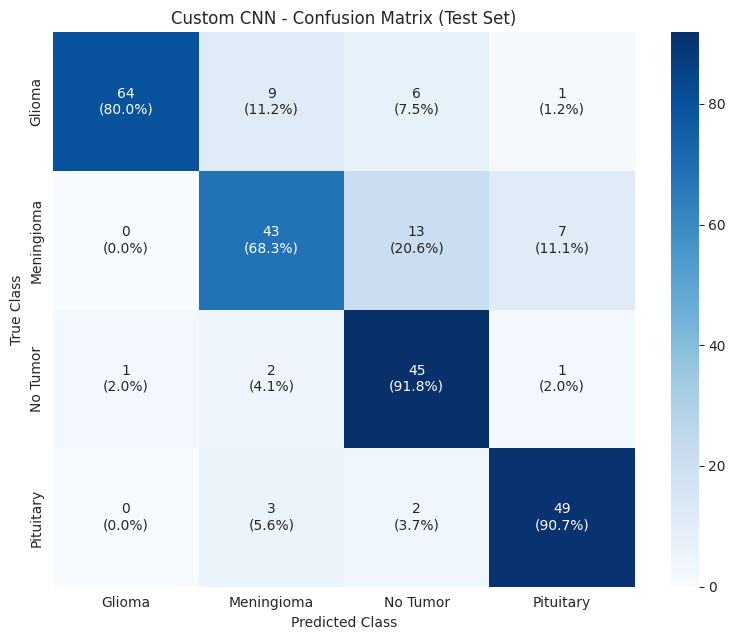

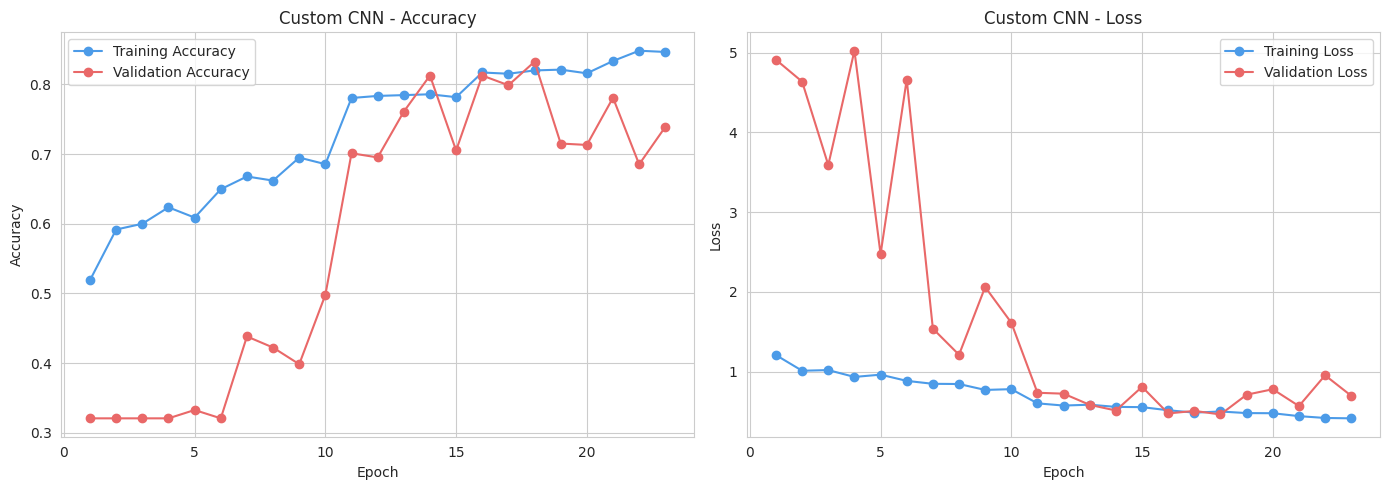

In [40]:
# evaluate the best saved Custom CNN on the validation and test sets
evaluate_and_report("Custom CNN")

#### **ML Model - 2, 3, 4, 5 : Transfer Learning with Pretrained Models**

##### **How Transfer Learning Works Here**

Pretrained models have already learned to recognise edges, textures and shapes from more than a million **ImageNet** photos. We reuse that knowledge instead of learning everything from zero.

- **Phase 1 (Feature Extraction)** — the pretrained base is **frozen** and only the new classification head (Global Average Pooling, Batch Normalization, Dropout, Dense and Softmax) is trained.

- **Phase 2 (Fine-Tuning)** — the **top 30 layers** of the base are unfrozen and trained with a very small learning rate so the model adapts to MRI images without forgetting what it already knows. Batch Normalization layers stay frozen for stable training.

- **Input scaling** — our pipeline gives every model pixels in the 0-1 range. A small `Rescaling` layer inside each model converts them to the range the pretrained network was originally trained with.

In [41]:
# configuration of the four pretrained models:
# builder = function that creates the network, scale/offset = convert our 0-1 pixels to the range the network expects
TL_CONFIG = {
    # MobileNetV2 and InceptionV3 and ResNet50V2 expect pixels between -1 and 1  ->  x * 2 - 1
    "MobileNetV2": {
        "builder": keras.applications.MobileNetV2,
        "scale": 2.0,
        "offset": -1.0,
    },
    "ResNet50V2": {
        "builder": keras.applications.ResNet50V2,
        "scale": 2.0,
        "offset": -1.0,
    },
    "InceptionV3": {
        "builder": keras.applications.InceptionV3,
        "scale": 2.0,
        "offset": -1.0,
    },
    # EfficientNetB0 expects pixels between 0 and 255 (it normalizes them inside)  ->  x * 255
    "EfficientNetB0": {
        "builder": keras.applications.EfficientNetB0,
        "scale": 255.0,
        "offset": 0.0,
    },
}


# function: builds a transfer learning model = pretrained base + new classification head
def build_transfer_model(model_name, input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    # get the settings of this model
    config = TL_CONFIG[model_name]
    # try to download the pretrained ImageNet weights
    try:
        base_model = config["builder"](
            include_top=False, weights="imagenet", input_shape=input_shape
        )
        weights_used = "ImageNet (pretrained)"
    # if the download fails (no internet), warn clearly and use random weights so the notebook still runs
    except Exception as error:
        print(
            f"WARNING: could not load ImageNet weights for {model_name} ({str(error)[:80]}...)."
        )
        print(
            "         Using RANDOM weights instead - results will be much worse. Check your internet connection and run again."
        )
        base_model = config["builder"](
            include_top=False, weights=None, input_shape=input_shape
        )
        weights_used = "random (ImageNet download failed)"
    # freeze the base model so its weights are not changed in phase 1
    base_model.trainable = False
    # input layer
    inputs = keras.Input(shape=input_shape)
    # convert our 0-1 pixels to the range this pretrained model expects
    x = layers.Rescaling(config["scale"], offset=config["offset"])(inputs)
    # pass the images through the pretrained base (training = False keeps its batch norm layers in inference mode)
    x = base_model(x, training=False)
    # average each feature map to a single number
    x = layers.GlobalAveragePooling2D()(x)
    # batch normalization stabilizes the new head
    x = layers.BatchNormalization()(x)
    # dropout reduces overfitting
    x = layers.Dropout(0.4)(x)
    # new fully connected layer
    x = layers.Dense(256, activation="relu")(x)
    # second dropout
    x = layers.Dropout(0.3)(x)
    # output layer with one probability per tumour class
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    # join everything into one model
    model = keras.Model(inputs, outputs, name=model_name.lower())
    # return the model, the base (needed for fine-tuning) and which weights were used
    return model, base_model, weights_used


# function: trains a transfer learning model in two phases
def run_transfer_learning(model_name):
    # path where the best version of this model is saved
    path = MODEL_PATHS[model_name]
    # protect the whole process so one failing model does not stop the notebook
    try:
        # build the model
        model, base_model, weights_used = build_transfer_model(model_name)
        # show the architecture
        model.summary()
        # remember the start time
        start = time.time()

        # ---------- Phase 1 : train only the new head ----------
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
            loss="categorical_crossentropy",
            metrics=["accuracy"],
        )
        print(f"\n--- Phase 1 : training the new head ({model_name}, base frozen) ---")
        phase1 = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=TL_HEAD_EPOCHS,
            callbacks=get_callbacks(path, EARLY_STOP_PATIENCE),
            class_weight=class_weights,
            verbose=FIT_VERBOSE,
        )
        # best validation loss reached in phase 1 (phase 2 must beat it to overwrite the saved file)
        best_phase1_loss = min(phase1.history["val_loss"])

        # ---------- Phase 2 : fine-tune the top layers ----------
        # unfreeze the base model
        base_model.trainable = True
        # freeze everything except the last FINE_TUNE_LAYERS layers
        for layer in base_model.layers[:-FINE_TUNE_LAYERS]:
            layer.trainable = False
        # keep batch normalization layers frozen, which is the recommended practice for fine-tuning
        for layer in base_model.layers:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False
        # compile again with a much smaller learning rate (required after changing trainable flags)
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=FINE_TUNE_LEARNING_RATE),
            loss="categorical_crossentropy",
            metrics=["accuracy"],
        )
        print(
            f"\n--- Phase 2 : fine-tuning the top {FINE_TUNE_LAYERS} layers ({model_name}) ---"
        )
        phase2 = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=TL_FINE_TUNE_EPOCHS,
            callbacks=get_callbacks(
                path, EARLY_STOP_PATIENCE, initial_threshold=best_phase1_loss
            ),
            class_weight=class_weights,
            verbose=FIT_VERBOSE,
        )

        # join the two histories so that we can draw one continuous curve
        results[model_name] = {
            "history": merge_histories(phase1.history, phase2.history),
            "fine_tune_start": len(phase1.history["loss"]),
            "train_time_min": (time.time() - start) / 60,
            "weights": weights_used,
        }
        print(
            f"\nTraining finished in {results[model_name]['train_time_min']:.1f} minutes. Best model saved to {path}"
        )
    # an out-of-memory error usually means the batch size is too large
    except tf.errors.ResourceExhaustedError:
        print(
            f"{model_name}: out of memory. Reduce BATCH_SIZE in the configuration cell."
        )
    # any other error is printed and the notebook continues with the next model
    except Exception as error:
        print(f"{model_name}: training failed -> {error}")

#### **ML Model - 2 : Transfer Learning - MobileNetV2**

##### **Step 1 : About the Model**

**MobileNetV2** is a very light network (about 3.4 million parameters) built for mobile devices. It is fast and small, which makes it a strong candidate for a web application.

##### **Step 2 : Build and Train (Phase 1 + Phase 2)**

In [42]:
# build, train (frozen base, then fine-tuning) and save the best MobileNetV2 model
run_transfer_learning("MobileNetV2")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,592,068 (9.89 MB)

 Trainable params: 331,524 (1.26 MB)

...


--- Phase 1 : training the new head (MobileNetV2, base frozen) ---
Epoch 1/10


53/53 - 46s - 870ms/step - accuracy: 0.7086 - loss: 0.9137 - val_accuracy: 0.7231 - val_loss: 0.8873 - learning_rate: 0.0010
Epoch 2/10


53/53 - 22s - 406ms/step - accuracy: 0.8106 - loss: 0.6160 - val_accuracy: 0.7649 - val_loss: 0.6772 - learning_rate: 0.0010
Epoch 3/10


53/53 - 21s - 390ms/step - accuracy: 0.8177 - loss: 0.5645 - val_accuracy: 0.8187 - val_loss: 0.5961 - learning_rate: 0.0010
Epoch 4/10
53/53 - 20s - 372ms/step - accuracy: 0.8401 - loss: 0.4863 - val_accuracy: 0.8187 - val_loss: 0.6026 - learning_rate: 0.0010
Epoch 5/10

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
53/53 - 22s - 409ms/step - accuracy: 0.8549 - loss: 0.4459 - val_accuracy: 0.7888 - val_loss: 0.6490 - learning_rate: 0.0010
Epoch 6/10
53/53 - 20s - 371ms/step - accuracy: 0.8832 - loss: 0.3775 - val_accuracy: 0.7968 - val_loss: 0.6304 - learning_rate: 3.0000e-04
Epoch 7/10


53/53 - 21s - 397ms/step - accuracy: 0.8761 - loss: 0.3553 - val_accuracy: 0.8406 - val_loss: 0.5270 - learning_rate: 3.0000e-04
Epoch 8/10
53/53 - 20s - 382ms/step - accuracy: 0.8720 - loss: 0.3667 - val_accuracy: 0.8267 - val_loss: 0.5781 - learning_rate: 3.0000e-04
Epoch 9/10

Epoch 9: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
53/53 - 20s - 370ms/step - accuracy: 0.8761 - loss: 0.3793 - val_accuracy: 0.8426 - val_loss: 0.5449 - learning_rate: 3.0000e-04
Epoch 10/10
53/53 - 22s - 409ms/step - accuracy: 0.8761 - loss: 0.3416 - val_accuracy: 0.8367 - val_loss: 0.5692 - learning_rate: 9.0000e-05
Restoring model weights from the end of the best epoch: 7.

--- Phase 2 : fine-tuning the top 30 layers (MobileNetV2) ---
Epoch 1/10
53/53 - 46s - 860ms/step - accuracy: 0.8814 - loss: 0.3435 - val_accuracy: 0.8466 - val_loss: 0.5411 - learning_rate: 1.0000e-05
Epoch 2/10
53/53 - 21s - 398ms/step - accuracy: 0.8785 - loss: 0.3193 - val_accuracy: 0.8426 - val_loss: 0.6147

##### **Step 3 : Evaluate (Metrics, Confusion Matrix and Training Curves)**

MobileNetV2 | Validation accuracy : 0.8406 | Test accuracy : 0.8537
MobileNetV2 | Test Precision (macro) : 0.8663 | Recall (macro) : 0.8576 | F1 (macro) : 0.8519

Classification Report (Test Set)
              precision    recall  f1-score   support

      Glioma       0.97      0.88      0.92        80
  Meningioma       0.85      0.70      0.77        63
    No Tumor       0.95      0.86      0.90        49
   Pituitary       0.69      1.00      0.82        54

    accuracy                           0.85       246
   macro avg       0.87      0.86      0.85       246
weighted avg       0.87      0.85      0.86       246



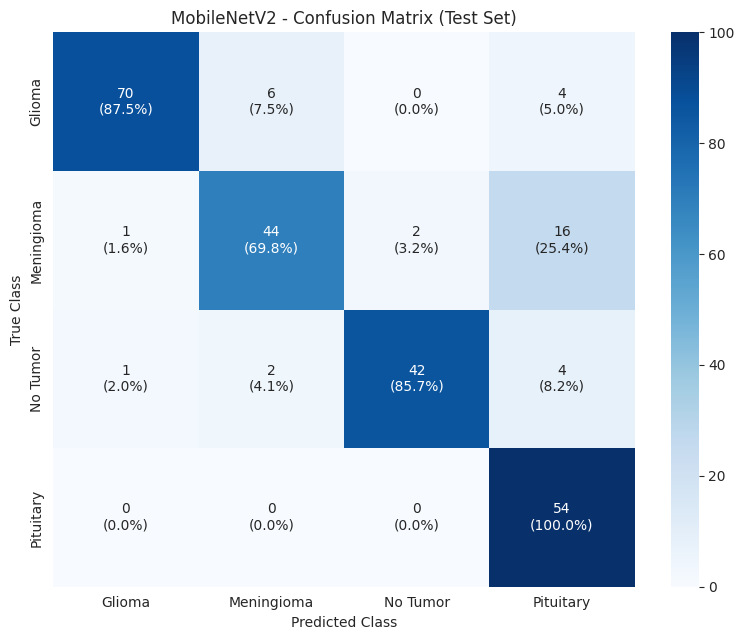

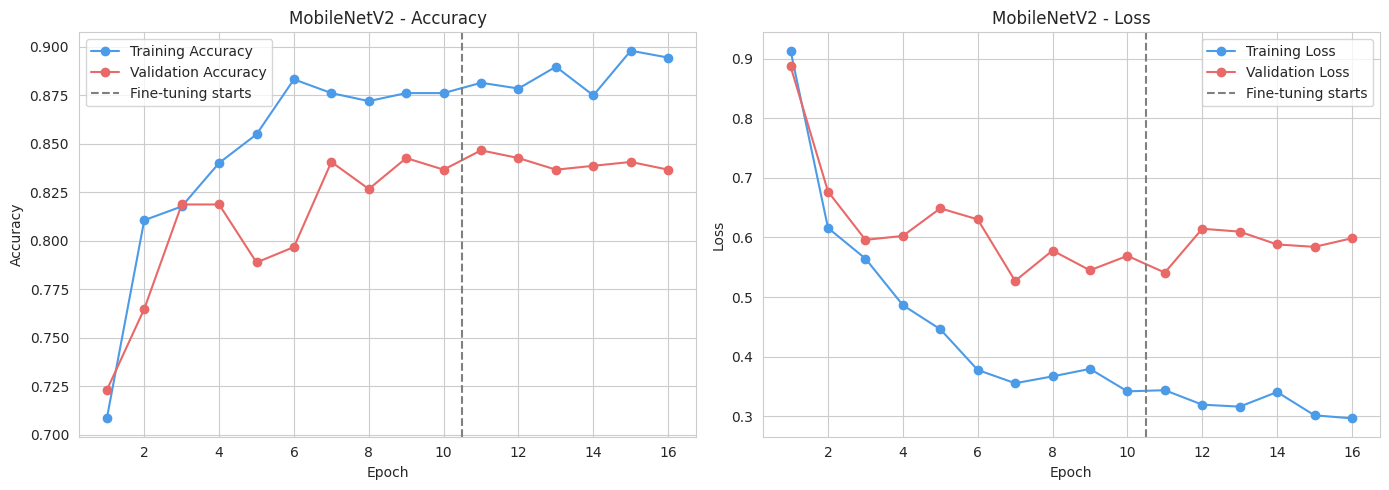

In [43]:
# evaluate the best saved MobileNetV2 model on validation and test data
evaluate_and_report(
    "MobileNetV2", fine_tune_start=results.get("MobileNetV2", {}).get("fine_tune_start")
)

#### **ML Model - 3 : Transfer Learning - ResNet50V2**

##### **Step 1 : About the Model**

**ResNet50V2** is a 50-layer network that uses *residual connections* (shortcuts) so that very deep networks can be trained easily. It is a heavier but powerful model. (The V2 version of ResNet50 is used because its input scaling is simple and fully supported inside the saved `.h5` model.)

##### **Step 2 : Build and Train (Phase 1 + Phase 2)**

In [44]:
# build, train (frozen base, then fine-tuning) and save the best ResNet50V2 model
run_transfer_learning("ResNet50V2")

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "resnet50v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,098,564 (91.93 MB)

 Trainable params: 529,668 (2.02 MB)

...

53/53 - 24s - 455ms/step - accuracy: 0.8973 - loss: 0.3071 - val_accuracy: 0.8904 - val_loss: 0.4201 - learning_rate: 3.0000e-04
Restoring model weights from the end of the best epoch: 10.

--- Phase 2 : fine-tuning the top 30 layers (ResNet50V2) ---
Epoch 1/10
53/53 - 53s - 1s/step - accuracy: 0.9091 - loss: 0.2709 - val_accuracy: 0.8845 - val_loss: 0.4267 - learning_rate: 1.0000e-05
Epoch 2/10


53/53 - 24s - 458ms/step - accuracy: 0.9115 - loss: 0.2679 - val_accuracy: 0.9004 - val_loss: 0.4090 - learning_rate: 1.0000e-05
Epoch 3/10


53/53 - 23s - 441ms/step - accuracy: 0.9062 - loss: 0.2683 - val_accuracy: 0.9044 - val_loss: 0.4029 - learning_rate: 1.0000e-05
Epoch 4/10


53/53 - 25s - 480ms/step - accuracy: 0.9251 - loss: 0.2212 - val_accuracy: 0.9064 - val_loss: 0.3843 - learning_rate: 1.0000e-05
Epoch 5/10
53/53 - 24s - 459ms/step - accuracy: 0.9174 - loss: 0.2211 - val_accuracy: 0.9004 - val_loss: 0.3864 - learning_rate: 1.0000e-05
Epoch 6/10


53/53 - 23s - 436ms/step - accuracy: 0.9245 - loss: 0.1990 - val_accuracy: 0.9104 - val_loss: 0.3563 - learning_rate: 1.0000e-05
Epoch 7/10
53/53 - 24s - 455ms/step - accuracy: 0.9316 - loss: 0.2031 - val_accuracy: 0.9064 - val_loss: 0.3713 - learning_rate: 1.0000e-05
Epoch 8/10

Epoch 8: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
53/53 - 23s - 430ms/step - accuracy: 0.9440 - loss: 0.1562 - val_accuracy: 0.8964 - val_loss: 0.3845 - learning_rate: 1.0000e-05
Epoch 9/10
53/53 - 23s - 437ms/step - accuracy: 0.9398 - loss: 0.1766 - val_accuracy: 0.8984 - val_loss: 0.3772 - learning_rate: 3.0000e-06
Epoch 10/10

Epoch 10: ReduceLROnPlateau reducing learning rate to 8.999999636216671e-07.
53/53 - 28s - 534ms/step - accuracy: 0.9410 - loss: 0.1543 - val_accuracy: 0.9064 - val_loss: 0.3743 - learning_rate: 3.0000e-06
Restoring model weights from the end of the best epoch: 6.

Training finished in 9.1 minutes. Best model saved to models/resnet50v2.h5


##### **Step 3 : Evaluate (Metrics, Confusion Matrix and Training Curves)**

ResNet50V2 | Validation accuracy : 0.9104 | Test accuracy : 0.8659
ResNet50V2 | Test Precision (macro) : 0.8705 | Recall (macro) : 0.8652 | F1 (macro) : 0.8627

Classification Report (Test Set)
              precision    recall  f1-score   support

      Glioma       0.92      0.91      0.92        80
  Meningioma       0.84      0.73      0.78        63
    No Tumor       0.95      0.84      0.89        49
   Pituitary       0.77      0.98      0.86        54

    accuracy                           0.87       246
   macro avg       0.87      0.87      0.86       246
weighted avg       0.87      0.87      0.86       246



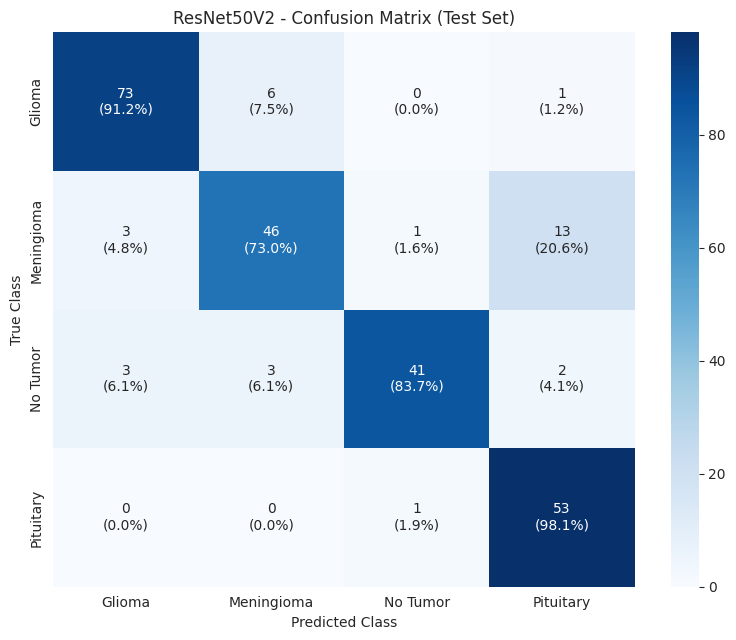

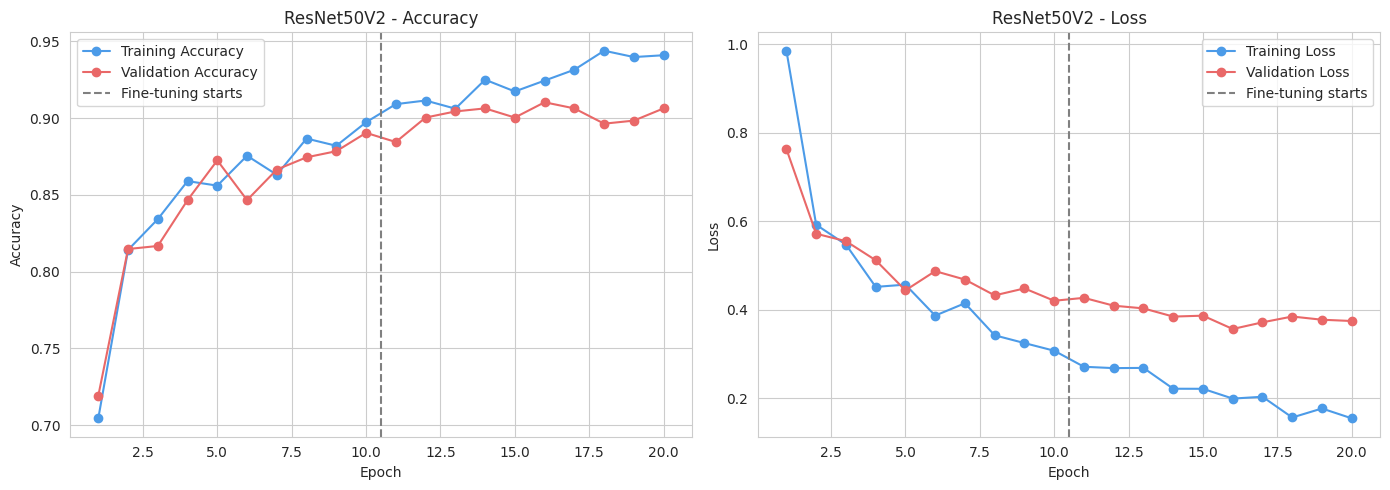

In [45]:
# evaluate the best saved ResNet50V2 model on validation and test data
evaluate_and_report(
    "ResNet50V2", fine_tune_start=results.get("ResNet50V2", {}).get("fine_tune_start")
)

#### **ML Model - 4 : Transfer Learning - InceptionV3**

##### **Step 1 : About the Model**

**InceptionV3** looks at the image with filters of several sizes at the same time, which helps it capture both small and large patterns. It is accurate but larger than MobileNetV2.

##### **Step 2 : Build and Train (Phase 1 + Phase 2)**

In [46]:
# build, train (frozen base, then fine-tuning) and save the best InceptionV3 model
run_transfer_learning("InceptionV3")

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "inceptionv3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_103         │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,336,548 (85.21 MB)

 Trainable params: 529,668 (2.02 MB)

...

53/53 - 23s - 429ms/step - accuracy: 0.8466 - loss: 0.4767 - val_accuracy: 0.8645 - val_loss: 0.4808 - learning_rate: 0.0010
Epoch 9/10
53/53 - 27s - 509ms/step - accuracy: 0.8649 - loss: 0.3830 - val_accuracy: 0.8546 - val_loss: 0.5368 - learning_rate: 0.0010
Epoch 10/10


53/53 - 27s - 518ms/step - accuracy: 0.8714 - loss: 0.3951 - val_accuracy: 0.8725 - val_loss: 0.4421 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 10.

--- Phase 2 : fine-tuning the top 30 layers (InceptionV3) ---
Epoch 1/10


53/53 - 60s - 1s/step - accuracy: 0.8673 - loss: 0.3597 - val_accuracy: 0.8745 - val_loss: 0.4327 - learning_rate: 1.0000e-05
Epoch 2/10


53/53 - 24s - 448ms/step - accuracy: 0.8802 - loss: 0.3414 - val_accuracy: 0.8805 - val_loss: 0.4208 - learning_rate: 1.0000e-05
Epoch 3/10


53/53 - 41s - 775ms/step - accuracy: 0.8796 - loss: 0.3454 - val_accuracy: 0.8865 - val_loss: 0.4062 - learning_rate: 1.0000e-05
Epoch 4/10
53/53 - 40s - 761ms/step - accuracy: 0.8826 - loss: 0.3109 - val_accuracy: 0.8865 - val_loss: 0.4138 - learning_rate: 1.0000e-05
Epoch 5/10

Epoch 5: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
53/53 - 28s - 521ms/step - accuracy: 0.8867 - loss: 0.3191 - val_accuracy: 0.8884 - val_loss: 0.4150 - learning_rate: 1.0000e-05
Epoch 6/10
53/53 - 27s - 501ms/step - accuracy: 0.9044 - loss: 0.2756 - val_accuracy: 0.8884 - val_loss: 0.4148 - learning_rate: 3.0000e-06
Epoch 7/10

Epoch 7: ReduceLROnPlateau reducing learning rate to 8.999999636216671e-07.
53/53 - 22s - 413ms/step - accuracy: 0.8979 - loss: 0.2810 - val_accuracy: 0.8845 - val_loss: 0.4148 - learning_rate: 3.0000e-06
Epoch 8/10
53/53 - 22s - 410ms/step - accuracy: 0.9027 - loss: 0.2785 - val_accuracy: 0.8865 - val_loss: 0.4179 - learning_rate: 9.0000e-07
Epoch 8: early s

##### **Step 3 : Evaluate (Metrics, Confusion Matrix and Training Curves)**

InceptionV3 | Validation accuracy : 0.8865 | Test accuracy : 0.8659
InceptionV3 | Test Precision (macro) : 0.8659 | Recall (macro) : 0.8631 | F1 (macro) : 0.8588

Classification Report (Test Set)
              precision    recall  f1-score   support

      Glioma       0.93      0.94      0.93        80
  Meningioma       0.85      0.70      0.77        63
    No Tumor       0.91      0.82      0.86        49
   Pituitary       0.78      1.00      0.88        54

    accuracy                           0.87       246
   macro avg       0.87      0.86      0.86       246
weighted avg       0.87      0.87      0.86       246



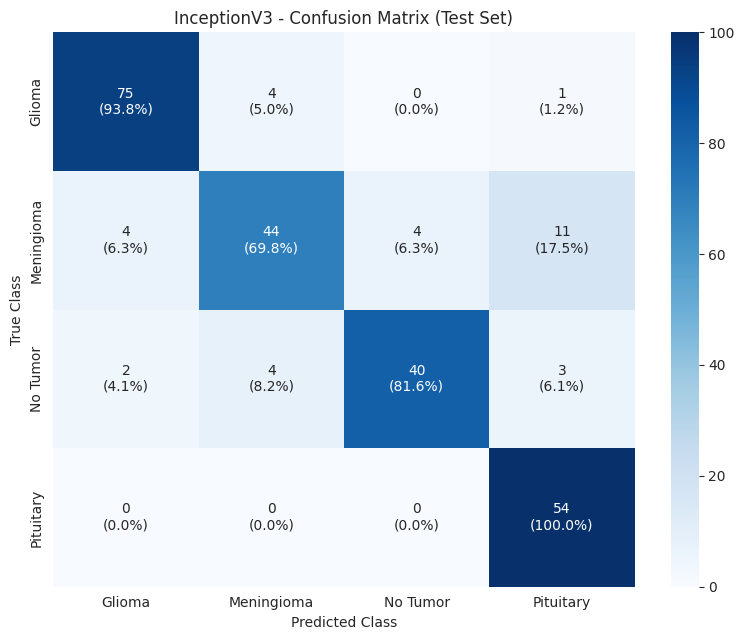

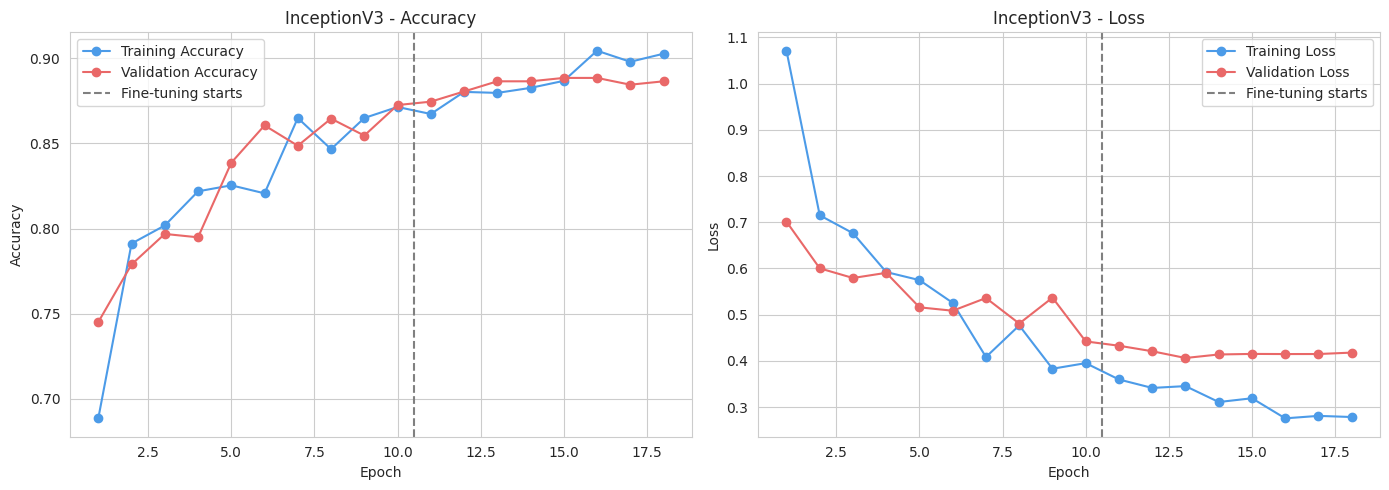

In [47]:
# evaluate the best saved InceptionV3 model on validation and test data
evaluate_and_report(
    "InceptionV3", fine_tune_start=results.get("InceptionV3", {}).get("fine_tune_start")
)

#### **ML Model - 5 : Transfer Learning - EfficientNetB0**

##### **Step 1 : About the Model**

**EfficientNetB0** balances network depth, width and image resolution using compound scaling, and gives a very good accuracy-to-size ratio.

##### **Step 2 : Build and Train (Phase 1 + Phase 2)**

In [48]:
# build, train (frozen base, then fine-tuning) and save the best EfficientNetB0 model
run_transfer_learning("EfficientNetB0")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_5 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_104         │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,655 (16.72 MB)

 Trainable params: 331,524 (1.26 MB)

...

53/53 - 22s - 419ms/step - accuracy: 0.8962 - loss: 0.3072 - val_accuracy: 0.8426 - val_loss: 0.4744 - learning_rate: 1.0000e-05
Epoch 6/10
53/53 - 20s - 385ms/step - accuracy: 0.8861 - loss: 0.3045 - val_accuracy: 0.8466 - val_loss: 0.4750 - learning_rate: 1.0000e-05
Epoch 7/10


53/53 - 21s - 396ms/step - accuracy: 0.8944 - loss: 0.2904 - val_accuracy: 0.8526 - val_loss: 0.4561 - learning_rate: 1.0000e-05
Epoch 8/10


53/53 - 46s - 872ms/step - accuracy: 0.8950 - loss: 0.2977 - val_accuracy: 0.8526 - val_loss: 0.4530 - learning_rate: 1.0000e-05
Epoch 9/10


53/53 - 27s - 501ms/step - accuracy: 0.8956 - loss: 0.2803 - val_accuracy: 0.8586 - val_loss: 0.4472 - learning_rate: 1.0000e-05
Epoch 10/10


53/53 - 36s - 677ms/step - accuracy: 0.9068 - loss: 0.2790 - val_accuracy: 0.8566 - val_loss: 0.4368 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 10.

Training finished in 10.3 minutes. Best model saved to models/efficientnetb0.h5


##### **Step 3 : Evaluate (Metrics, Confusion Matrix and Training Curves)**

EfficientNetB0 | Validation accuracy : 0.7510 | Test accuracy : 0.7480
EfficientNetB0 | Test Precision (macro) : 0.7943 | Recall (macro) : 0.7335 | F1 (macro) : 0.7331

Classification Report (Test Set)
              precision    recall  f1-score   support

      Glioma       0.68      0.99      0.80        80
  Meningioma       0.83      0.40      0.54        63
    No Tumor       0.95      0.73      0.83        49
   Pituitary       0.72      0.81      0.77        54

    accuracy                           0.75       246
   macro avg       0.79      0.73      0.73       246
weighted avg       0.78      0.75      0.73       246



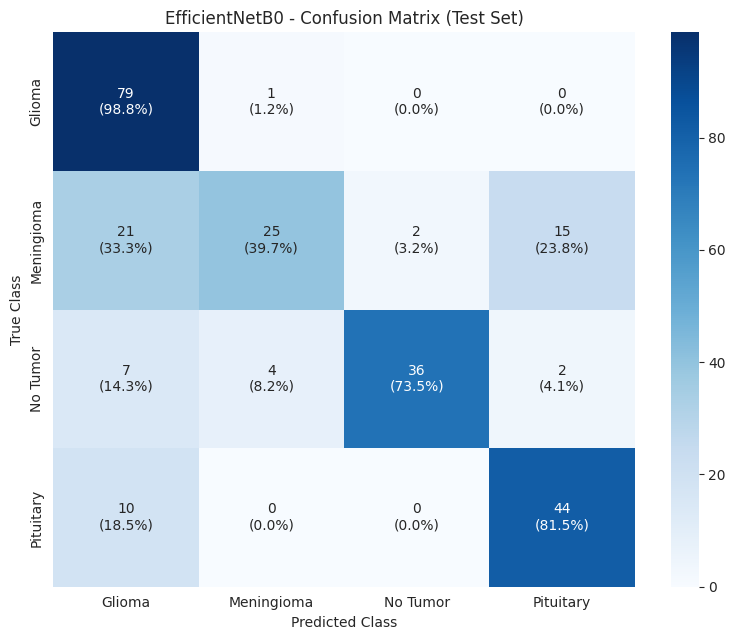

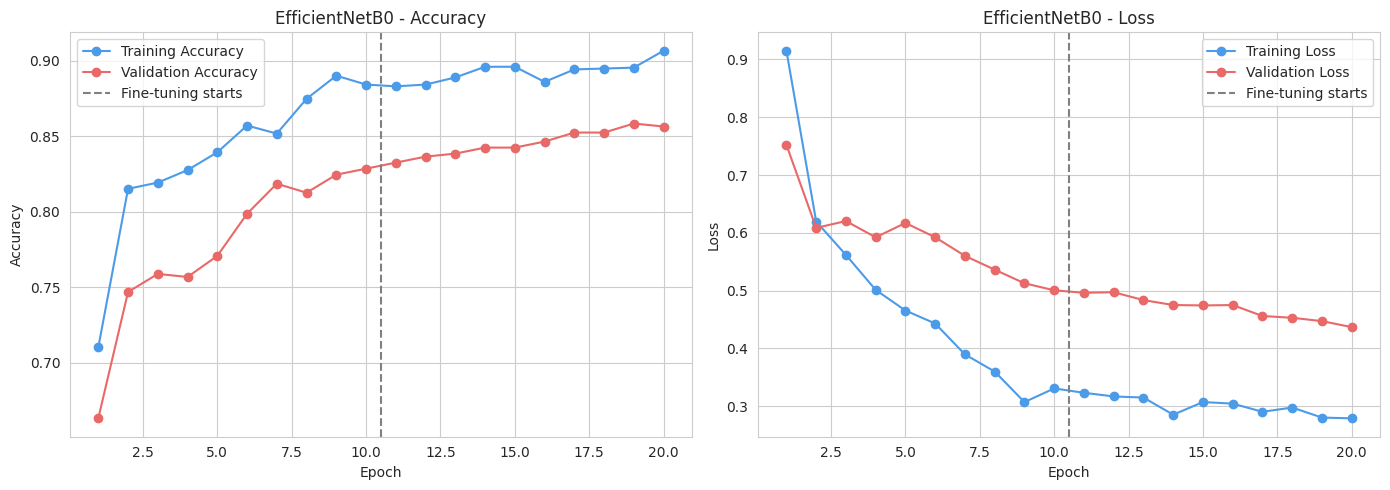

In [49]:
# evaluate the best saved EfficientNetB0 model on validation and test data
evaluate_and_report(
    "EfficientNetB0",
    fine_tune_start=results.get("EfficientNetB0", {}).get("fine_tune_start"),
)

##### **Key Insights**

- **Training strategy for every model:** EarlyStopping stops training when the validation loss stops improving, ModelCheckpoint keeps only the best version of the model on disk (`.h5`), and ReduceLROnPlateau lowers the learning rate when progress stalls.

- **Transfer learning models** are trained in two phases. The dashed vertical line in each training chart marks the point where fine-tuning starts. A small jump or a smoother curve right after that line is expected, because the top layers of the network can now adapt to MRI images.

- **How to read the training curves:** a large gap between training and validation accuracy means **overfitting**; both curves staying low means **underfitting**. The Dropout, Batch Normalization, augmentation and class-weight choices in this project are there to keep that gap small.

- **How to read the confusion matrix:** the diagonal shows correct predictions, and every off-diagonal number is a specific mistake (for example a glioma predicted as meningioma). In a medical setting, tumours predicted as *No Tumor* are the most serious mistakes.

#### **7. Model Evaluation Overview**

##### **Chart - 11 : Validation Accuracy Curves of All Models**

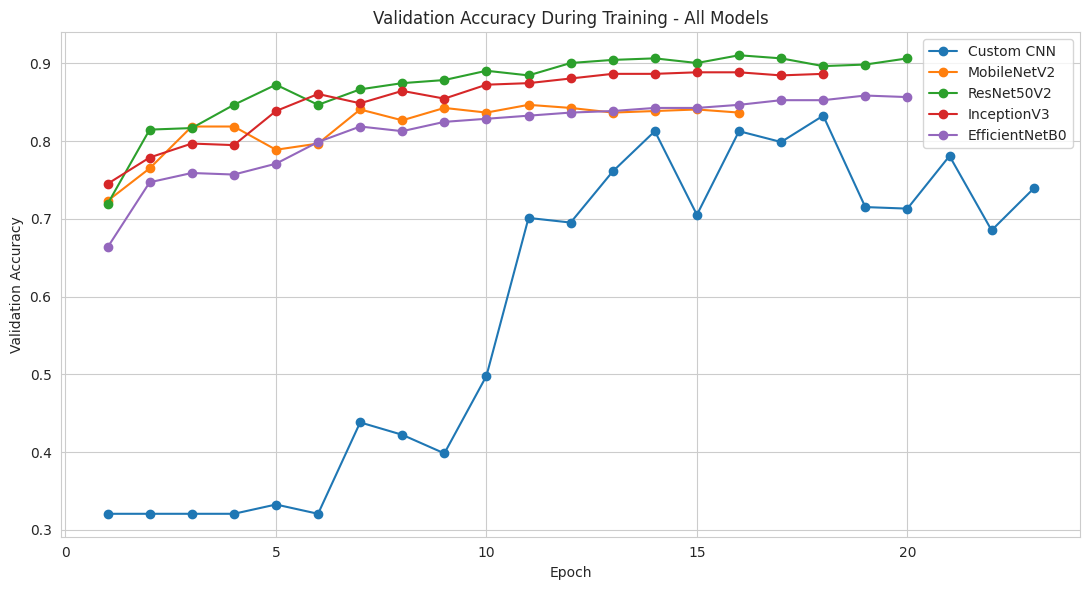

In [50]:
# keep only the models that were trained successfully
trained_models = [
    name for name in MODEL_PATHS if name in results and "test" in results[name]
]
# stop with a message if nothing was trained
if not trained_models:
    print("No trained models found. Run the training cells first.")
else:
    plt.figure(figsize=(11, 6))
    # draw one validation-accuracy curve per model
    for name in trained_models:
        history = results[name]["history"]
        plt.plot(
            range(1, len(history["val_accuracy"]) + 1),
            history["val_accuracy"],
            marker="o",
            label=name,
        )
    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy")
    plt.title("Validation Accuracy During Training - All Models")
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        "images/chart11_validation_accuracy_all_models.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

##### **Chart - 12 : Per-Class F1-Score of All Models (Test Set)**

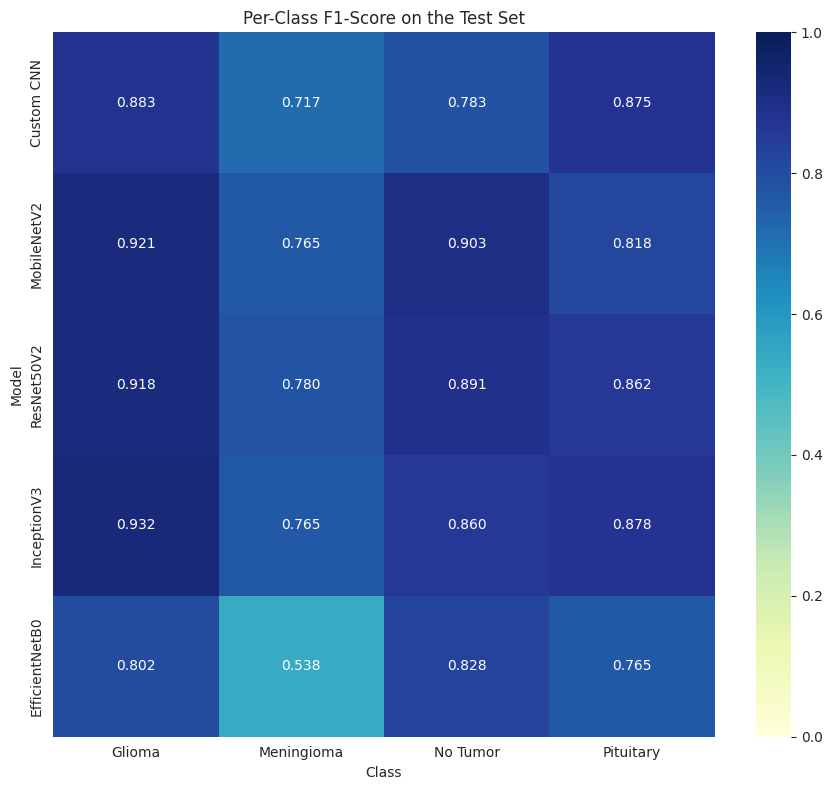

In [51]:
# build a table: rows = models, columns = classes, values = F1-score on the test set
if trained_models:
    f1_table = pd.DataFrame(
        {name: results[name]["test"]["per_class_f1"] for name in trained_models},
        index=[PRETTY_NAMES[c] for c in class_names],
    ).T

    plt.figure(figsize=(9, 1.2 * len(trained_models) + 2))
    # heatmap with the numbers written inside the cells
    sns.heatmap(f1_table, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0, vmax=1)
    plt.xlabel("Class")
    plt.ylabel("Model")
    plt.title("Per-Class F1-Score on the Test Set")
    plt.tight_layout()
    plt.savefig("images/chart12_per_class_f1.png", dpi=300, bbox_inches="tight")
    plt.show()

##### **Chart - 13 : Confusion Matrices of All Models (Test Set, Row-Normalised)**

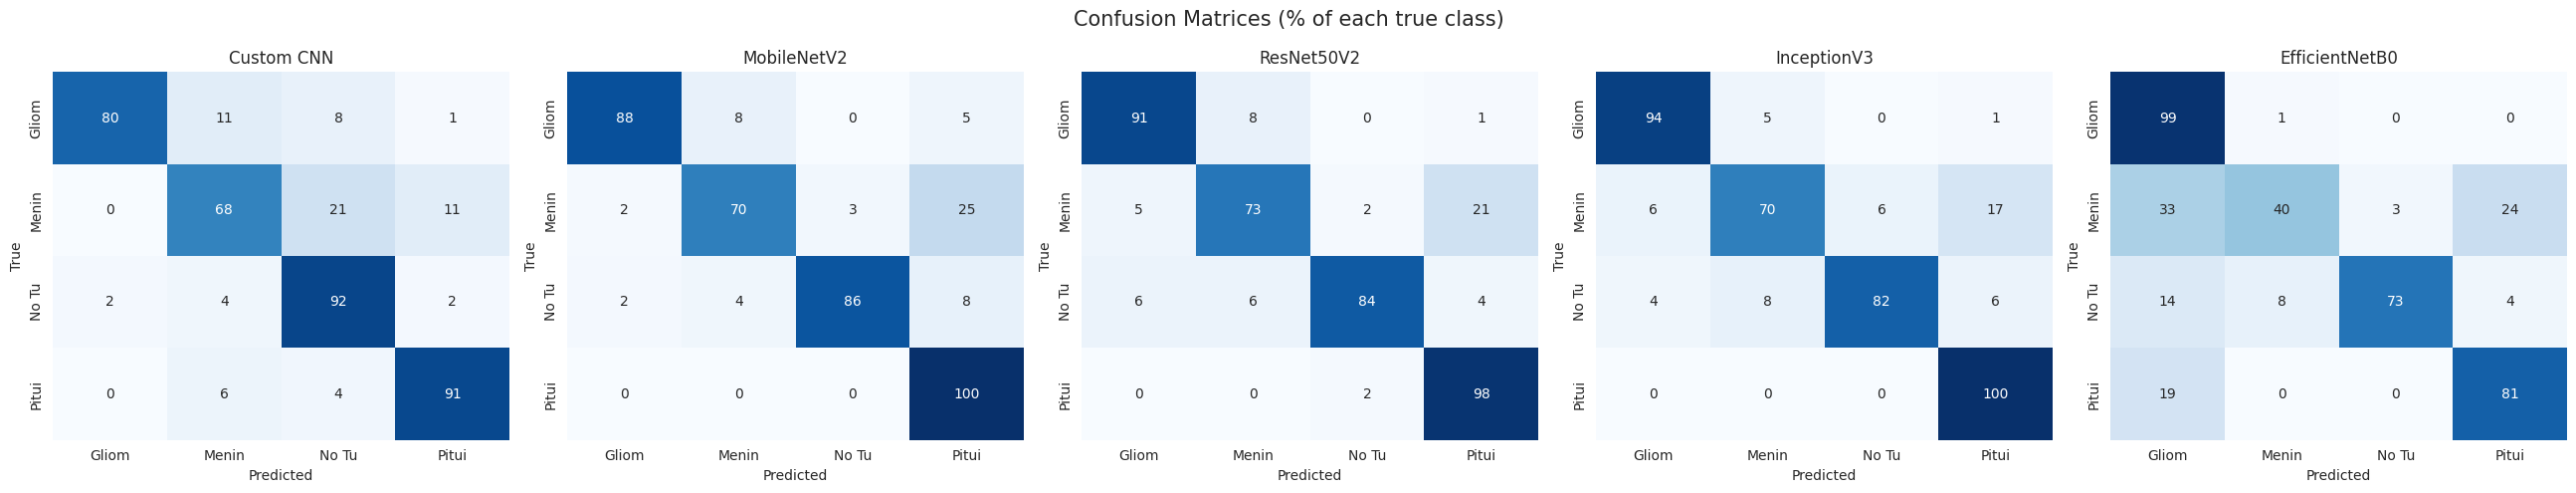

In [52]:
# draw all confusion matrices side by side so mistakes are easy to compare
if trained_models:
    fig, axes = plt.subplots(
        1, len(trained_models), figsize=(5.2 * len(trained_models), 5), squeeze=False
    )
    # one heatmap per model
    for ax, name in zip(axes[0], trained_models):
        # normalize each row to percentages
        cm = results[name]["confusion_matrix"]
        cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100
        sns.heatmap(
            cm_percent,
            annot=True,
            fmt=".0f",
            cmap="Blues",
            cbar=False,
            ax=ax,
            vmin=0,
            vmax=100,
            xticklabels=[PRETTY_NAMES[c][:5] for c in class_names],
            yticklabels=[PRETTY_NAMES[c][:5] for c in class_names],
        )
        ax.set_title(name)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
    plt.suptitle("Confusion Matrices (% of each true class)", fontsize=15)
    plt.tight_layout()
    plt.savefig(
        "images/chart13_confusion_matrices_all_models.png", dpi=300, bbox_inches="tight"
    )
    plt.show()

##### **Key Insights**


- The **validation accuracy curves** show how quickly each model learns and how stable it is. Pretrained models usually reach a high accuracy in very few epochs, while the custom CNN, which starts from random weights, normally needs more epochs.

- The **per-class F1 heatmap** shows which tumour types are easy or hard for each model. Classes with a darker colour are learned better, and a class that is pale for every model is intrinsically difficult for this dataset.

- The **confusion matrices** make it easy to see whether different models make the *same* mistakes (which points to genuinely ambiguous images) or *different* mistakes (which would make an ensemble useful).

- The exact numbers for this run are printed by the summary cell below this section.


In [53]:
# automatic summary of the evaluation, generated from the real numbers of this run
if trained_models:
    # model with the highest test accuracy
    best_acc_model = max(trained_models, key=lambda m: results[m]["test"]["accuracy"])
    print(
        f"- Highest test accuracy : {best_acc_model} ({results[best_acc_model]['test']['accuracy'] * 100:.2f}%)"
    )
    # find the hardest class for every model = the class with the lowest F1
    for name in trained_models:
        f1_values = results[name]["test"]["per_class_f1"]
        hardest = class_names[int(np.argmin(f1_values))]
        print(
            f"- {name:<15}: hardest class is {PRETTY_NAMES[hardest]} (F1 = {f1_values.min():.3f})"
        )
    # remind the reader if any model had to use random weights
    for name in trained_models:
        if "random (ImageNet" in results[name]["weights"]:
            print(
                f"- WARNING: {name} used random weights (ImageNet download failed), so its result is not a true transfer-learning result."
            )

- Highest test accuracy : ResNet50V2 (86.59%)
- Custom CNN     : hardest class is Meningioma (F1 = 0.717)
- MobileNetV2    : hardest class is Meningioma (F1 = 0.765)
- ResNet50V2     : hardest class is Meningioma (F1 = 0.780)
- InceptionV3    : hardest class is Meningioma (F1 = 0.765)
- EfficientNetB0 : hardest class is Meningioma (F1 = 0.538)


#### **8. Model Comparison**

##### **Comparison Table - Custom CNN vs Pretrained Models**

In [54]:
# build one row of numbers for every trained model
comparison_rows = []
for name in trained_models:
    # shortcuts to the stored results
    val, test = results[name]["val"], results[name]["test"]
    # one dictionary = one row of the table
    comparison_rows.append(
        {
            "Model": name,
            "Weights": (
                "ImageNet"
                if results[name]["weights"].startswith("ImageNet")
                else "Random"
            ),
            "Val Accuracy": val["accuracy"],
            "Val F1 (Macro)": val["f1_macro"],
            "Test Accuracy": test["accuracy"],
            "Test Precision (Macro)": test["precision_macro"],
            "Test Recall (Macro)": test["recall_macro"],
            "Test F1 (Macro)": test["f1_macro"],
            "Tumour Sensitivity": test["tumour_sensitivity"],
            "Parameters (M)": results[name]["params"] / 1e6,
            "Size (MB)": results[name]["size_mb"],
            "Inference (ms/image)": results[name]["inference_ms"],
            "Training Time (min)": results[name]["train_time_min"],
        }
    )

# convert to a DataFrame, sorted by validation F1 so the best model is on top
comparison_df = (
    pd.DataFrame(comparison_rows)
    .sort_values("Val F1 (Macro)", ascending=False)
    .reset_index(drop=True)
)
# show the table rounded to 4 decimals
display(comparison_df.round(4))
# save the table as a CSV file (the Streamlit app reads it to display model information)
comparison_df.round(4).to_csv(
    os.path.join(MODELS_DIR, "model_comparison.csv"), index=False
)
print("Comparison table saved to", os.path.join(MODELS_DIR, "model_comparison.csv"))

,Model,Weights,Val Accuracy,Val F1 (Macro),Test Accuracy,Test Precision (Macro),Test Recall (Macro),Test F1 (Macro),Tumour Sensitivity,Parameters (M),Size (MB),Inference (ms/image),Training Time (min)
0,ResNet50V2,ImageNet,0.9104,0.9068,0.8659,0.8705,0.8652,0.8627,0.9898,24.0986,206.4232,3.4092,9.0865
1,InceptionV3,ImageNet,0.8865,0.8829,0.8659,0.8659,0.8631,0.8588,0.9797,22.3365,129.1791,2.6469,8.9661
2,MobileNetV2,ImageNet,0.8406,0.8326,0.8537,0.8663,0.8576,0.8519,0.9898,2.5921,12.7814,1.2762,6.3603
3,Custom CNN,Random,0.8327,0.8252,0.8171,0.8164,0.8271,0.8143,0.8934,1.2326,14.2295,5.3277,11.7187
4,EfficientNetB0,ImageNet,0.7510,0.7381,0.7480,0.7943,0.7335,0.7331,0.9898,4.3837,31.0453,2.6517,10.2954


Comparison table saved to models/model_comparison.csv


> **Tumour Sensitivity** = of all scans that truly contain a tumour (glioma, meningioma or pituitary), the percentage that the model did **not** label as "No Tumor". In a medical setting, missing a tumour is the most dangerous mistake, so this number matters as much as overall accuracy.

##### **Chart - 14 : Accuracy, Precision, Recall and F1-Score Comparison**

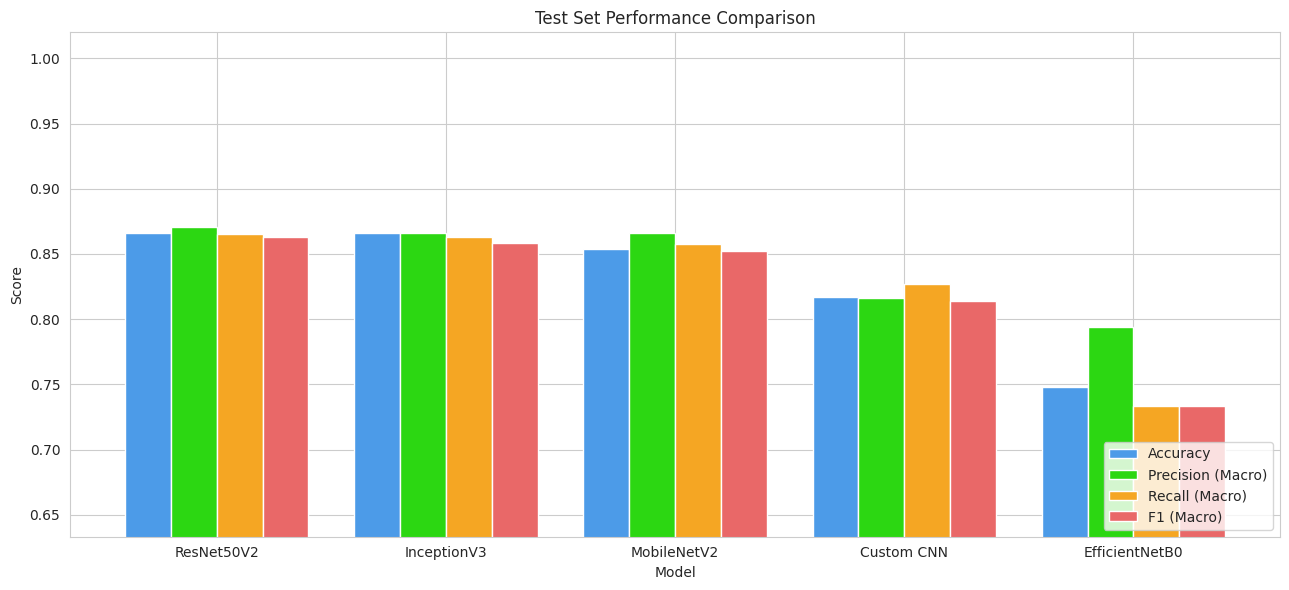

In [55]:
# grouped bar chart of the four main test metrics for every model
if len(comparison_df) > 0:
    # metrics to plot and their colours
    metric_columns = [
        "Test Accuracy",
        "Test Precision (Macro)",
        "Test Recall (Macro)",
        "Test F1 (Macro)",
    ]
    metric_colors = ["#4C9BE8", "#2CD712", "#F5A623", "#E96868"]
    # x position of each model group and bar width
    x_positions = np.arange(len(comparison_df))
    bar_width = 0.2

    plt.figure(figsize=(13, 6))
    # draw one set of bars per metric
    for i, (metric, color) in enumerate(zip(metric_columns, metric_colors)):
        # shift each metric a little so the bars sit side by side
        plt.bar(
            x_positions + i * bar_width,
            comparison_df[metric],
            bar_width,
            label=metric.replace("Test ", ""),
            color=color,
        )
    # center the model names under the groups
    plt.xticks(x_positions + 1.5 * bar_width, comparison_df["Model"])
    # zoom the y axis to make small differences visible
    plt.ylim(max(0, comparison_df[metric_columns].values.min() - 0.1), 1.02)
    plt.xlabel("Model")
    plt.ylabel("Score")
    plt.title("Test Set Performance Comparison")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig("images/chart14_metric_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()

##### **Chart - 15 : Efficiency Comparison (Model Size, Inference Speed, Training Time)**

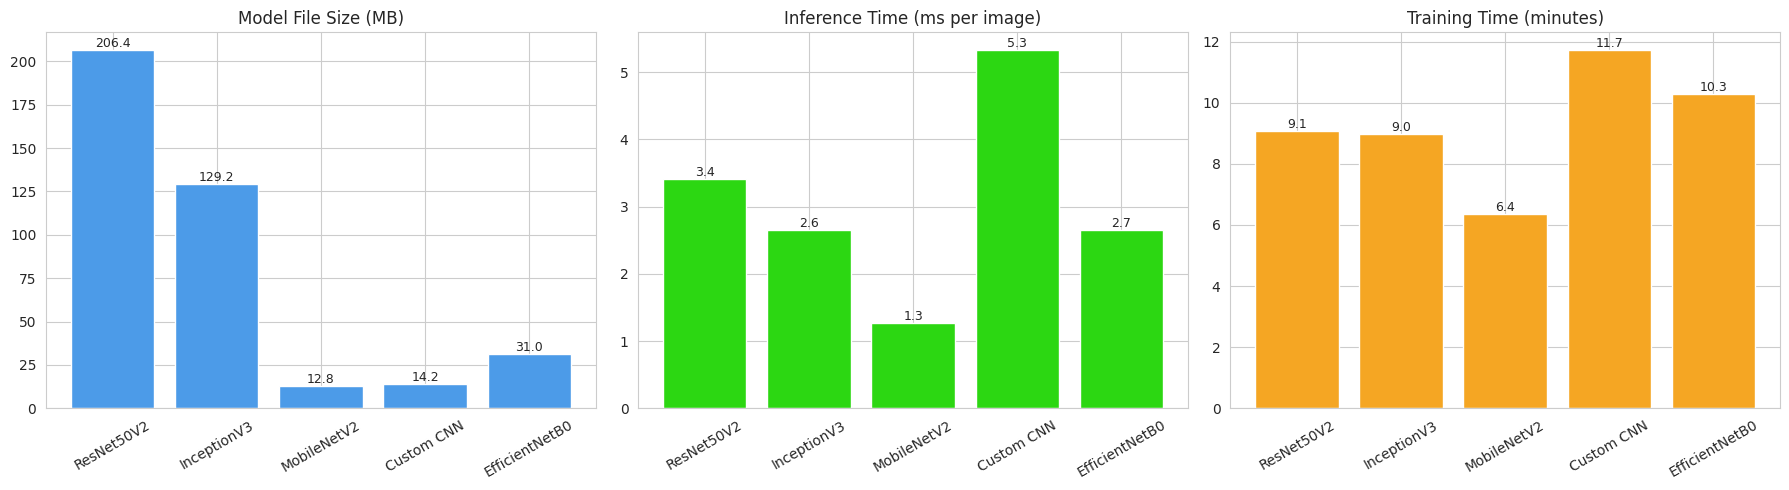

In [56]:
# three small bar charts about efficiency
if len(comparison_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    # (column name, chart title, colour)
    for ax, (column, title, color) in zip(
        axes,
        [
            ("Size (MB)", "Model File Size (MB)", "#4C9BE8"),
            ("Inference (ms/image)", "Inference Time (ms per image)", "#2CD712"),
            ("Training Time (min)", "Training Time (minutes)", "#F5A623"),
        ],
    ):
        # draw the bars
        bars = ax.bar(comparison_df["Model"], comparison_df[column], color=color)
        # write the value above every bar
        ax.bar_label(bars, fmt="%.1f", fontsize=9)
        ax.set_title(title)
        ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.savefig(
        "images/chart15_efficiency_comparison.png", dpi=300, bbox_inches="tight"
    )
    plt.show()

##### **Best Model Selection**

The best model is chosen using the **validation** set (macro F1-score), **not** the test set. This keeps the test set completely unseen, so the final test numbers are an honest estimate. If two models are tied, the smaller model is preferred because it is cheaper to deploy.

The final decision also considers **reliability** (tumour sensitivity and the weakest class) and **efficiency** (size and inference time), which are shown in the table above.

In [57]:
# sort by validation F1 (higher is better) and then by file size (smaller is better) to break ties
ranked = comparison_df.sort_values(
    ["Val F1 (Macro)", "Size (MB)"], ascending=[False, True]
).reset_index(drop=True)
# the first row is the winner
best_model_name = ranked.loc[0, "Model"]

# print a short, automatically written verdict
best_row = ranked.loc[0]
print("=" * 60)
print(f"BEST MODEL FOR DEPLOYMENT : {best_model_name}")
print("=" * 60)
print(f"Validation F1 (macro) : {best_row['Val F1 (Macro)']:.4f}")
print(f"Test accuracy : {best_row['Test Accuracy']:.4f}")
print(f"Test F1 (macro) : {best_row['Test F1 (Macro)']:.4f}")
print(f"Tumour sensitivity : {best_row['Tumour Sensitivity']:.4f}")
print(f"Model size : {best_row['Size (MB)']:.1f} MB")
print(f"Inference time : {best_row['Inference (ms/image)']:.1f} ms per image")

# compare with the custom CNN to answer "custom vs pretrained"
if "Custom CNN" in ranked["Model"].values and best_model_name != "Custom CNN":
    cnn_row = ranked[ranked["Model"] == "Custom CNN"].iloc[0]
    print(
        f"\nCustom CNN test accuracy {cnn_row['Test Accuracy']:.4f}  vs  {best_model_name} {best_row['Test Accuracy']:.4f}"
    )
elif best_model_name == "Custom CNN":
    print("\nThe custom CNN built from scratch is the best model in this run.")

BEST MODEL FOR DEPLOYMENT : ResNet50V2
Validation F1 (macro) : 0.9068
Test accuracy : 0.8659
Test F1 (macro) : 0.8627
Tumour sensitivity : 0.9898
Model size : 206.4 MB
Inference time : 3.4 ms per image

Custom CNN test accuracy 0.8171  vs  ResNet50V2 0.8659


##### **Detailed Diagnostic - Misclassified Test Images (Best Model)**

ResNet50V2 misclassified 33 of 246 test images.


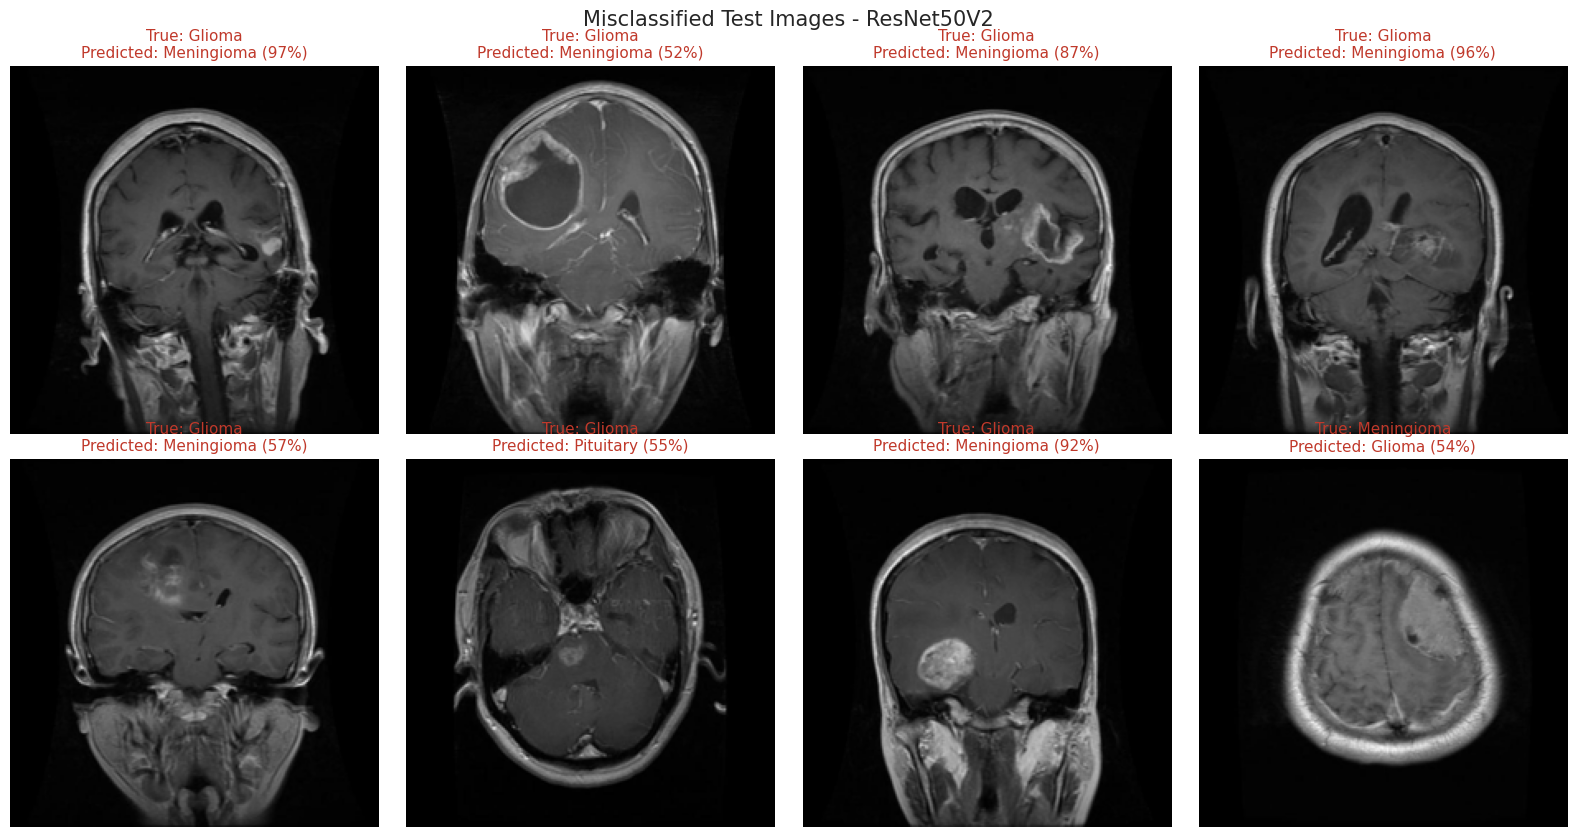

In [58]:
# show up to 8 test images that the best model got wrong, with true label, prediction and confidence
best_test = results[best_model_name]["test"]
# positions of wrong predictions
wrong_positions = np.where(best_test["y_pred"] != test_df["label_id"].values)[0]
print(
    f"{best_model_name} misclassified {len(wrong_positions)} of {len(test_df)} test images."
)

# only draw if there is something to show
if len(wrong_positions) > 0:
    # at most 8 images
    show_positions = wrong_positions[:8]
    fig, axes = plt.subplots(2, 4, figsize=(16, 8.5))
    # flatten the 2 x 4 grid into one list of cells
    for ax in axes.ravel():
        ax.axis("off")
    # draw each wrong prediction
    for ax, position in zip(axes.ravel(), show_positions):
        # row of the table for this image
        row = test_df.iloc[position]
        # open and resize the image
        with Image.open(row["filepath"]) as img:
            ax.imshow(img.convert("RGB").resize(IMG_SIZE))
        # predicted class and its confidence
        predicted = best_test["y_pred"][position]
        confidence = best_test["probabilities"][position][predicted] * 100
        # title shows True vs Predicted
        ax.set_title(
            f"True: {PRETTY_NAMES[row['label']]}\nPredicted: {PRETTY_NAMES[index_to_class[predicted]]} ({confidence:.0f}%)",
            fontsize=11,
            color="#C0392B",
        )
    plt.suptitle(f"Misclassified Test Images - {best_model_name}", fontsize=15)
    plt.tight_layout()
    plt.savefig("images/chart16_misclassified_images.png", dpi=300, bbox_inches="tight")
    plt.show()

##### **Key Insights**


- Models are compared on **three things**: accuracy-type metrics (accuracy, precision, recall, F1-score), **reliability** (tumour sensitivity and the weakest class) and **efficiency** (model size, inference time, training time).

- The best model is chosen using **validation macro F1-score**, so the test set is only used for the final, unbiased report.

- The **misclassified images** show what kind of scans confuse the best model. Looking at them is important in medical imaging, because they can reveal systematic problems (for example, very dark scans or unusual viewing planes) that a single accuracy number hides.

- Because 23.2% of the test images share a scan ID with a training image (Section 3), the test scores are probably somewhat optimistic compared with brand-new patients. Treat the numbers as a strong demonstration result, not as clinical validation.


In [59]:
# automatic comparison summary generated from the numbers of this run
print("Summary of this run")
print("-" * 60)
# fastest model and smallest model
fastest = comparison_df.loc[comparison_df["Inference (ms/image)"].idxmin(), "Model"]
smallest = comparison_df.loc[comparison_df["Size (MB)"].idxmin(), "Model"]
best_sens = comparison_df.loc[comparison_df["Tumour Sensitivity"].idxmax(), "Model"]
print(f"- Best on validation F1 : {best_model_name}")
print(
    f"- Best test accuracy : {comparison_df.loc[comparison_df['Test Accuracy'].idxmax(), 'Model']}"
)
print(
    f"- Highest tumour sensitivity : {best_sens} ({comparison_df['Tumour Sensitivity'].max() * 100:.2f}%)"
)
print(f"- Fastest model : {fastest}")
print(f"- Smallest model : {smallest}")
# average accuracy of pretrained vs custom CNN
pretrained = comparison_df[comparison_df["Model"] != "Custom CNN"]["Test Accuracy"]
if "Custom CNN" in comparison_df["Model"].values and len(pretrained) > 0:
    print(
        f"- Custom CNN accuracy {comparison_df.loc[comparison_df['Model'] == 'Custom CNN', 'Test Accuracy'].iloc[0]:.4f} vs average pretrained accuracy {pretrained.mean():.4f}"
    )

Summary of this run
------------------------------------------------------------
- Best on validation F1 : ResNet50V2
- Best test accuracy : ResNet50V2
- Highest tumour sensitivity : ResNet50V2 (98.98%)
- Fastest model : MobileNetV2
- Smallest model : MobileNetV2
- Custom CNN accuracy 0.8171 vs average pretrained accuracy 0.8333


#### **9. Save the Final Model**

##### **Save the Best Model as `best_model.h5`**

In [60]:
# every model was already saved as its own .h5 file during training (ModelCheckpoint).
# here we copy the winner to a fixed name that the Streamlit app loads: models/best_model.h5
BEST_MODEL_PATH = os.path.join(MODELS_DIR, "best_model.h5")

# copy the file inside try/except in case something goes wrong with the disk
try:
    # shutil.copy copies the file to the new name
    shutil.copy(MODEL_PATHS[best_model_name], BEST_MODEL_PATH)
    print(f"Best model ({best_model_name}) saved to {BEST_MODEL_PATH}")
except Exception as error:
    print("Could not save the best model:", error)

# save the class names in the same order as the model outputs, plus which model won
class_info = {
    "class_names": class_names,
    "best_model": best_model_name,
    "img_height": IMG_HEIGHT,
    "img_width": IMG_WIDTH,
}
# write the settings to a small json file
with open(os.path.join(MODELS_DIR, "class_names.json"), "w") as file:
    json.dump(class_info, file, indent=2)
print("Class information saved to", os.path.join(MODELS_DIR, "class_names.json"))

Best model (ResNet50V2) saved to models/best_model.h5
Class information saved to models/class_names.json


##### **Verify the Saved Model (Reload and Compare Predictions)**

In [61]:
# reload the saved file and check that it gives the same predictions as before - this proves the file is valid
try:
    # load the file from disk
    reloaded_model = keras.models.load_model(BEST_MODEL_PATH, compile=False)
    # predict on the whole test set again
    reloaded_probabilities = reloaded_model.predict(test_ds, verbose=0)
    # probabilities stored earlier for the same model
    original_probabilities = results[best_model_name]["test"]["probabilities"]
    # check that both are (almost) identical
    same = np.allclose(reloaded_probabilities, original_probabilities, atol=1e-4)
    print("Reloaded model gives identical predictions :", same)
    # show the saved file size
    print(f"File size : {os.path.getsize(BEST_MODEL_PATH) / (1024 * 1024):.1f} MB")
except Exception as error:
    print("Verification failed:", error)

Reloaded model gives identical predictions : True
File size : 206.4 MB


##### **List of All Saved Files**

In [62]:
# show every file in the models folder with its size
for file_name in sorted(os.listdir(MODELS_DIR)):
    # full path of the file
    path = os.path.join(MODELS_DIR, file_name)
    # skip hidden files
    if not file_name.startswith("."):
        print(f"{file_name:<28} {os.path.getsize(path) / (1024 * 1024):>8.2f} MB")

best_model.h5                  206.42 MB
class_names.json                 0.00 MB
custom_cnn.h5                   14.23 MB
efficientnetb0.h5               31.05 MB
inceptionv3.h5                 129.18 MB
mobilenetv2.h5                  12.78 MB
model_comparison.csv             0.00 MB
resnet50v2.h5                  206.42 MB


#### **10. Prediction on a Single MRI Image (Inference Function)**

This is exactly what the Streamlit app does behind the scenes: open the image, convert it to RGB, resize to 224 x 224, scale pixels to 0-1, and ask the model for the class probabilities.

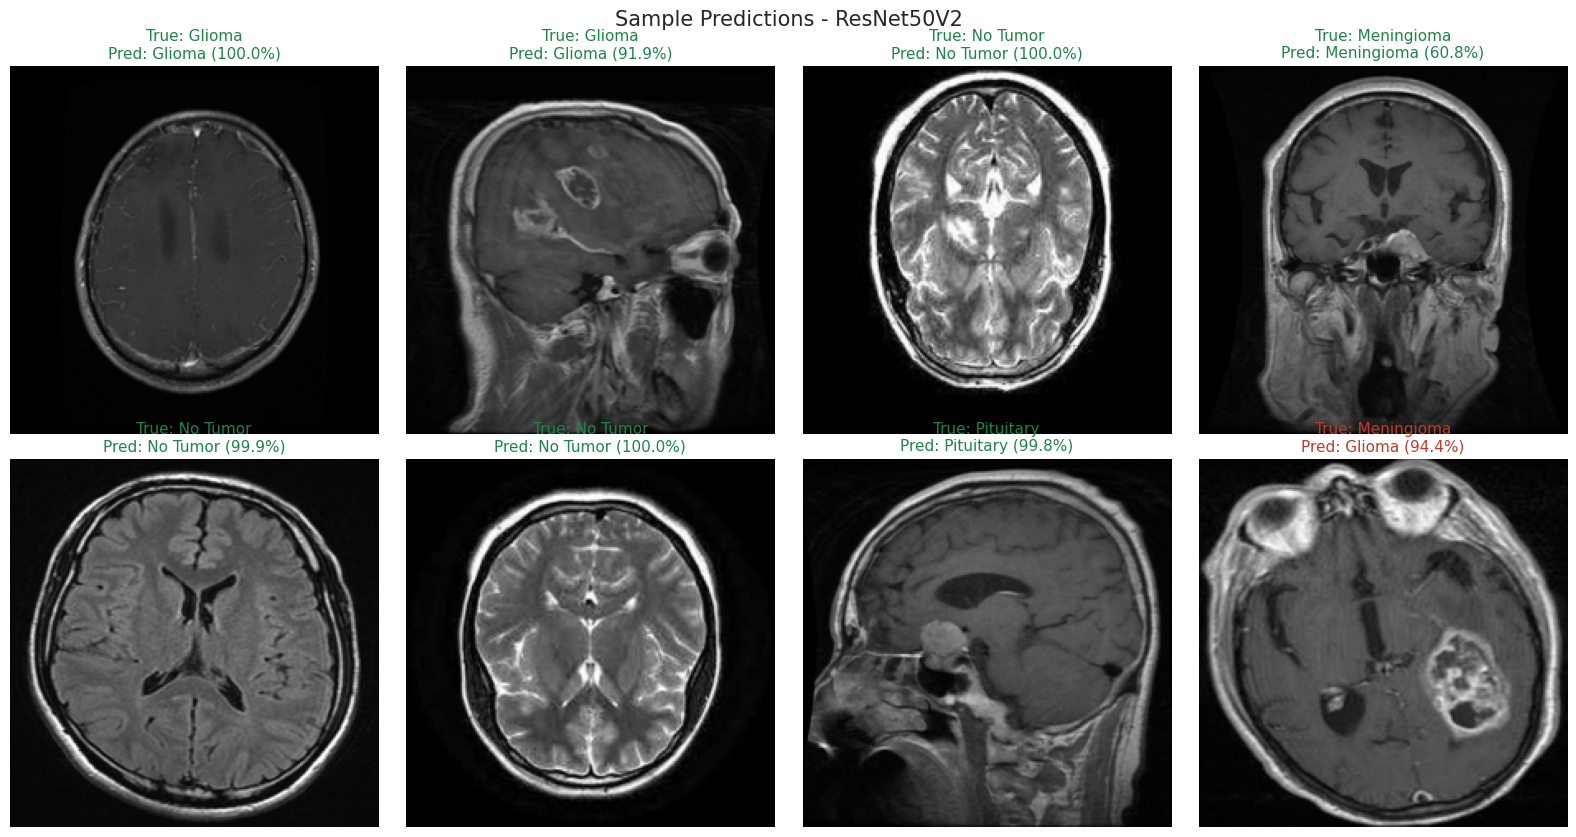

In [63]:
# function: predicts the tumour class of ONE image file
def predict_mri_image(image_path, model, class_list):
    # try to open and process the image
    try:
        # open the image and make sure it has 3 colour channels
        with Image.open(image_path) as img:
            img = img.convert("RGB").resize(IMG_SIZE)
        # convert to a numpy array and scale pixels to 0-1 (same as training)
        array = np.asarray(img, dtype=np.float32) / 255.0
        # add a batch dimension: (224, 224, 3) -> (1, 224, 224, 3)
        batch = np.expand_dims(array, axis=0)
        # the model returns one probability per class
        probabilities = model.predict(batch, verbose=0)[0]
        # class with the highest probability
        best_index = int(np.argmax(probabilities))
        # return a small dictionary with everything the user needs
        return {
            "class": class_list[best_index],
            "confidence": float(probabilities[best_index]),
            "probabilities": dict(zip(class_list, probabilities.tolist())),
        }
    # a missing file or a damaged image gives a clear message instead of a crash
    except FileNotFoundError:
        return {"error": f"File not found: {image_path}"}
    except Exception as error:
        return {"error": f"Could not process the image: {error}"}


# test the function on 8 random test images using the saved best model
final_model = keras.models.load_model(BEST_MODEL_PATH, compile=False)
# pick 8 random rows from the test table
demo_rows = test_df.sample(n=min(8, len(test_df)), random_state=SEED)

fig, axes = plt.subplots(2, 4, figsize=(16, 8.5))
for ax in axes.ravel():
    ax.axis("off")
# predict and draw each demo image
for ax, row in zip(axes.ravel(), demo_rows.itertuples()):
    # run the prediction
    output = predict_mri_image(row.filepath, final_model, class_names)
    # skip images that could not be processed
    if "error" in output:
        ax.set_title(output["error"], fontsize=8)
        continue
    # show the image
    with Image.open(row.filepath) as img:
        ax.imshow(img.convert("RGB").resize(IMG_SIZE))
    # green title if correct, red if wrong
    correct = output["class"] == row.label
    ax.set_title(
        f"True: {PRETTY_NAMES[row.label]}\nPred: {PRETTY_NAMES[output['class']]} ({output['confidence'] * 100:.1f}%)",
        color="#1E8449" if correct else "#C0392B",
        fontsize=11,
    )

plt.suptitle(f"Sample Predictions - {best_model_name}", fontsize=15)

plt.tight_layout()

plt.savefig("images/chart17_sample_predictions.png", dpi=300, bbox_inches="tight")

plt.show()

#### **11. Streamlit Web Application**

The file **`app.py`** (next to this notebook) is the deployed application. It lets a user:

- **Upload** a brain MRI image (JPG, JPEG or PNG),
- **See the predicted tumour type** together with the model confidence,
- **See the probability of every class** as a bar chart and a table,
- **Choose between the saved models** in the sidebar (the best model is selected by default),
- **Read a clear warning** when the model is not confident and a medical disclaimer.

**How to run it locally**

1. Make sure `models/best_model.h5` and `models/class_names.json` exist (they are created by this notebook).
2. Open a terminal in the project folder and run:

```
streamlit run app.py
```

**How to deploy for free** — push the project folder to GitHub (including the `models` folder and `requirements.txt`) and create a new app on Streamlit Community Cloud pointing to `app.py`.

In [64]:
# check that everything the Streamlit app needs exists
required_files = [
    "app.py",
    "requirements.txt",
    os.path.join(MODELS_DIR, "best_model.h5"),
    os.path.join(MODELS_DIR, "class_names.json"),
]

# check each file and print OK / MISSING
for path in required_files:
    status = "OK     " if os.path.exists(path) else "MISSING"
    print(f"{status} {path}")

print("\nStart the app with :  streamlit run app.py")

MISSING app.py
MISSING requirements.txt
OK      models/best_model.h5
OK      models/class_names.json

Start the app with :  streamlit run app.py


#### **Conclusion**


##### **Data and Preprocessing**

- The dataset is clean (no missing, corrupted, duplicated or mislabelled files) and every image has the same resolution. Resizing to 224 x 224, normalising to 0-1, class weighting and on-the-fly augmentation form a complete preprocessing pipeline.

- A **possible overlap between splits** was found (about 19% of validation and 23% of test images share a scan ID with a training image). The project keeps the official split, but reported scores should be seen as optimistic for unseen patients.

##### **Modelling**

- A **custom CNN** built from scratch and **four ImageNet-pretrained models** (MobileNetV2, ResNet50V2, InceptionV3, EfficientNetB0) were trained with the same data, the same callbacks (EarlyStopping, ModelCheckpoint, ReduceLROnPlateau) and the same evaluation code, which makes the comparison fair.

- Transfer learning models were trained in two phases (frozen base, then fine-tuning of the top layers) and the custom CNN was trained end to end.

- The best model was chosen on the **validation** set, and then evaluated once on the **test** set using accuracy, precision, recall, F1-score, confusion matrices and tumour sensitivity.

##### **Deployment**

- The winning model is saved as `models/best_model.h5` and served by the Streamlit application (`app.py`), which shows the predicted tumour type, the confidence and the probability of every class.

##### **Limitations and Future Work**

- **Not a medical device:** predictions must always be reviewed by a qualified radiologist.

- **Patient-level splitting:** a split by patient (not by image) would give a more honest estimate of real-world performance.

- **Explainability:** adding Grad-CAM heatmaps would show which part of the scan the model used for its decision.

- **More data and external validation:** testing on scans from other hospitals and scanners would show how well the model generalises.

- **Ensembling:** combining the two or three best models could reduce the remaining errors.

The final numbers of your own run are printed in the **Final Project Summary** cell above.

In [65]:
# final automatic summary: prints the real results of this run so the conclusion is always up to date
print("=" * 70)
print("FINAL PROJECT SUMMARY")
print("=" * 70)
print(
    f"Images used : {len(df)} (train {len(train_df)}, valid {len(valid_df)}, test {len(test_df)})"
)
print(f"Classes : {', '.join(PRETTY_NAMES[c] for c in class_names)}")
print(f"Models trained : {', '.join(trained_models)}")
print(f"Best model : {best_model_name}")
print(
    f"Best model test acc. : {results[best_model_name]['test']['accuracy'] * 100:.2f}%"
)
print(f"Best model test F1 : {results[best_model_name]['test']['f1_macro']:.4f}")
print(
    f"Tumour sensitivity : {results[best_model_name]['test']['tumour_sensitivity'] * 100:.2f}%"
)
print(f"Deployment file : {BEST_MODEL_PATH}")
print("=" * 70)

FINAL PROJECT SUMMARY
Images used : 2443 (train 1695, valid 502, test 246)
Classes : Glioma, Meningioma, No Tumor, Pituitary
Models trained : Custom CNN, MobileNetV2, ResNet50V2, InceptionV3, EfficientNetB0
Best model : ResNet50V2
Best model test acc. : 86.59%
Best model test F1 : 0.8627
Tumour sensitivity : 98.98%
Deployment file : models/best_model.h5
